# Notebook 05 - Panel LP-IV, NLP Integration, Network Heterogeneity, and Causal Forest

## Research questions

1. **External validity:** does the CHN-USA geopolitical oil-price channel hold across China's other bilateral relationships?
2. **NLP contribution:** does the composite GPR index change causal estimates when used as a panel nuisance control?
3. **Multi-outcome:** which channels does the shock transmit through?
4. **Network heterogeneity:** does China's network position moderate the causal transmission?
5. **Dyad heterogeneity:** what characteristics explain why signs differ across dyads?

## Sections

| Section | Content |
|---------|---------|
| A | Setup, data loading, d2PRI construction for 12 dyads |
| B | First-stage F-statistics; instrument validity |
| C | Panel LP-IV for 8 valid dyads; sign consistency; heatmap |
| D | CHN-USA annotated IRF with bilateral event history |
| E | Composite GPR as panel nuisance control |
| F | IVW pooled estimator across 3 strong dyads |
| G | Anderson-Rubin CIs for weak-instrument dyads |
| H | Network metrics: PRI-based and ICEWS-based |
| I | Multi-outcome LP-IV: Brent, industrial production, VIX |
| J | Causal Forest with attention-share moderator + placebo |
| K | Graph Attention Network: spillover structure |
| K2 | GAT controlled regression |
| L | Meta-regression: explaining cross-dyad sign heterogeneity |
| M | Notebook summary and findings |
| App | Instrument validity diagnostics |

## Key results

| Result | Value |
|--------|-------|
| Valid dyads (F>=10) | 8 of 12 |
| Sign consistent at h=6 (cooperation -> lower WTI) | CHN-USA, CHN-JPN, CHN-AUS, CHN-GBR |
| CHN-USA composite GPR deviation at h=6 | +5.7% (stable) |
| WTI sig horizons | 21/49 |
| Brent | 11/49 sig |
| indpro | 0/49 (no real-economy channel) |
| VIX | 5/49 (reduced form) |
| Causal forest r(attention_share, CATE) | -0.803, p<0.0001 (saturation) |
| GAT centrality r with log WTI | +0.586, p<0.0001 |

## Literature

| Method | Reference |
|--------|-----------|
| LP-IV | Jorda (2005) AER; Ramey (2016) NBER |
| Stock-Yogo weak IV | Stock & Yogo (2005) |
| Anderson-Rubin CI | Anderson & Rubin (1949) |
| IVW meta-analysis | Borenstein et al. (2009) |
| Causal Forest | Wager & Athey (2018) JASA; Athey et al. (2019) AOS |
| GAT | Velickovic et al. (2018) ICLR |
| Meta-regression | Thompson & Sharp (1999) Stat Med |


---
## Section A - Imports and Data Loading

### A1. Libraries

`networkx` constructs the bilateral event graph. `econml.CausalForestDML` implements the doubly-robust causal forest (Athey et al. 2019). `torch` enables the Graph Attention Network (Velickovic et al. 2018). All are optional; cells degrade gracefully if absent.


In [2]:
from pathlib import Path
import warnings, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats
import statsmodels.api as sm
from statsmodels.tools.tools import add_constant
from linearmodels.iv import IV2SLS

try:
    import networkx as nx; HAS_NX = True; print("networkx: OK")
except ImportError:
    HAS_NX = False; print("networkx missing — pip install networkx")

try:
    from econml.dml import CausalForestDML
    from sklearn.ensemble import RandomForestRegressor
    HAS_ECONML = True; print("econml: OK")
except ImportError:
    HAS_ECONML = False; print("econml missing — pip install econml")

warnings.filterwarnings('ignore')
np.random.seed(42)
plt.rcParams.update({'figure.dpi':120,'figure.facecolor':'white',
                     'axes.spines.top':False,'axes.spines.right':False,'font.size':9})

ROOT    = Path(r'C:\Users\HP\Desktop\replication+contribution')
DATA    = ROOT / 'data'
NLP_DIR = DATA / '03_nlp'
OUT_03C = ROOT / 'outputs' / '03c'
OUT_04  = ROOT / 'outputs' / '04_diagnostics'
OUT     = ROOT / 'outputs' / '05_panel'
OUT.mkdir(parents=True, exist_ok=True)

Z90 = 1.645; Z95 = 1.960; HMAX = 48
HORIZONS = list(range(0, HMAX+1))
print(f"Outputs → {OUT}")

networkx: OK
econml: OK
Outputs → C:\Users\HP\Desktop\replication+contribution\outputs\05_panel


### A2. Saadaoui dataset: 12 bilateral PRI series

The published dataset contains log PRI for all 12 China bilateral dyads, 1990-01 to 2022-02, 386 observations, 100% coverage for every dyad.

**d2PRI construction:** CHN-USA and CHN-JPN have d2PRI pre-computed in the published data. For the remaining 10 dyads a 5-month rolling mean is applied before computing the second difference. Pre-smoothing prevents near-collinearity between the constructed d2PRI and the lpri treatment lags in the first stage — without it, the first-stage F-statistic for smooth PRI series (CHN-PAK, std=0.055) would reflect spurious collinearity.

**Composite GPR merge:** the composite GPR panel from NB02 is pivoted by dyad and merged as `cgpr_{dyad}` columns. CHN-KOR is absent (not among the original 11 dyads).

**ICEWS attention share:** monthly ratio of CHN-USA ICEWS event volume to total China bilateral event volume. Available for 314 of 386 months (1995 onwards).


In [3]:
def stata_month_to_datetime(period):
    """Robust: handles both pre-parsed Timestamps (read_stata) and raw integers (CSV)."""
    if pd.api.types.is_datetime64_any_dtype(period):
        return pd.to_datetime(period)
    s = pd.to_numeric(period, errors='coerce')
    if s.notna().sum() > 0:
        years  = (1960 + (s // 12)).astype('Int64')
        months = ((s % 12) + 1).astype('Int64')
        return pd.to_datetime({'year': years, 'month': months, 'day': 1}, errors='coerce')
    return pd.Series(pd.NaT, index=period.index)

# ── Load Saadaoui data ────────────────────────────────────────────────────────
dta_path = DATA / 'Saadaoui_2026_JCE.dta'
csv_path = DATA / 'Saadaoui_2026_JCE.csv'

if dta_path.exists():
    df = pd.read_stata(dta_path)
    # .dta: Period may already be Timestamp OR still an integer
    if 'date' not in df.columns or df['date'].isna().all():
        df['date'] = stata_month_to_datetime(df['Period'])
    else:
        df['date'] = pd.to_datetime(df['date'], errors='coerce')
    # Fallback: if still NaT, try the integer formula on Period
    if df['date'].isna().all() and 'Period' in df.columns:
        df['date'] = stata_month_to_datetime(df['Period'])
else:
    df = pd.read_csv(csv_path)
    df['date'] = stata_month_to_datetime(df['Period'])

df = df.sort_values('date').reset_index(drop=True)
print(f"Loaded: {df.shape}  |  Date range: {df['date'].min().date()} → {df['date'].max().date()}")

df['dllgop']   = df['llgop'].diff()
df['dl2lgop']  = df['l2lgop'].diff()
df['F2_d2pri'] = df['d2pri'].shift(-2)
BASE_CONTROLS  = ['llwip', 'dllgop', 'l2lwip', 'dl2lgop']

DYADS = {
    'CHN-USA': ('lpri',       'd2pri',       'dlpri'),
    'CHN-JPN': ('lpri_jp',    'd2pri_jp',    'dlpri_jp'),
    'CHN-AUS': ('lpri_aus',   'd2pri_aus',   'dlpri_aus'),
    'CHN-FRA': ('lpri_fra',   'd2pri_fra',   'dlpri_fra'),
    'CHN-DEU': ('lpri_ger',   'd2pri_ger',   'dlpri_ger'),
    'CHN-GBR': ('lpri_uk',    'd2pri_uk',    'dlpri_uk'),
    'CHN-RUS': ('lpri_rus',   'd2pri_rus',   'dlpri_rus'),
    'CHN-IND': ('lpri_india', 'd2pri_india', 'dlpri_india'),
    'CHN-IDN': ('lpri_indo',  'd2pri_indo',  'dlpri_indo'),
    'CHN-PAK': ('lpri_pak',   'd2pri_pak',   'dlpri_pak'),
    'CHN-VNM': ('lpri_vn',    'd2pri_vn',    'dlpri_vn'),
    'CHN-KOR': ('lpri_cds',   'd2pri_cds',   'dlpri_cds'),
}

SMOOTHING_WINDOW = 5
print("\nConstructing d²PRI:")
for dyad, (lpri_col, d2_col, _) in DYADS.items():
    if d2_col in df.columns and df[d2_col].notna().sum() > 100:
        print(f"  {dyad:10s}: {d2_col} pre-computed ({df[d2_col].notna().sum()} non-null) ✓")
        continue
    sc = f'smooth_{lpri_col}'
    df[sc]    = df[lpri_col].rolling(SMOOTHING_WINDOW, min_periods=1, center=False).mean()
    sp        = df[sc]
    df[d2_col] = sp - 2*sp.shift(1) + sp.shift(2)
    print(f"  {dyad:10s}: {d2_col} constructed from smoothed series ({df[d2_col].notna().sum()} non-null)")

# ── Merge composite GPR panel ─────────────────────────────────────────────────
comp_path = OUT_03C / 'composite_gpr_panel.parquet'
if comp_path.exists():
    comp = pd.read_parquet(comp_path)
    comp['date'] = pd.to_datetime(comp['date'])
    # Pivot: one row per date per dyad → merge dyad-specific columns into df
    # For panel use, create a mapping: date → dyad → composite_gpr
    comp_map = comp.set_index(['date','dyad'])['composite_gpr'].unstack('dyad')
    comp_map.columns = [f'cgpr_{c.replace("-","_")}' for c in comp_map.columns]
    df = df.merge(comp_map.reset_index(), on='date', how='left')
    cgpr_cols = [c for c in df.columns if c.startswith('cgpr_')]
    print(f"\nComposite GPR columns merged: {cgpr_cols}")
    print(f"  CHN-USA coverage: {df['cgpr_CHN_USA'].notna().sum()}/{len(df)}")
else:
    cgpr_cols = []
    print("\nComposite GPR parquet not found — panel will use BASE_CONTROLS only")

# ── ICEWS attention share (needs correct date) ────────────────────────────────
icews_path = NLP_DIR / 'icews' / 'icews_monthly_panel_1995_2022.csv'
if icews_path.exists():
    ic = pd.read_csv(icews_path)
    ic['date'] = pd.to_datetime(ic['date']).dt.to_period('M').dt.to_timestamp()
    tot   = ic.groupby('date')['icews_event_count'].sum()
    usa_ev = ic[ic['dyad']=='CHN-USA'].groupby('date')['icews_event_count'].sum()
    att    = (usa_ev / tot.replace(0, np.nan)).rename('usa_attention_share')
    df['date_ms'] = df['date'].dt.to_period('M').dt.to_timestamp()
    df = df.merge(att.reset_index().rename(columns={'date':'date_ms'}), on='date_ms', how='left')
    print(f"  usa_attention_share (ICEWS): {df['usa_attention_share'].notna().sum()}/{len(df)} obs")
else:
    df['usa_attention_share'] = np.nan
    print("  ICEWS not found")

print(f"\nFinal df shape: {df.shape}")
print(f"Date range confirmed: {df['date'].min().date()} → {df['date'].max().date()}")

Loaded: (386, 49)  |  Date range: 1990-01-01 → 2022-02-01

Constructing d²PRI:
  CHN-USA   : d2pri pre-computed (386 non-null) ✓
  CHN-JPN   : d2pri_jp pre-computed (386 non-null) ✓
  CHN-AUS   : d2pri_aus constructed from smoothed series (384 non-null)
  CHN-FRA   : d2pri_fra constructed from smoothed series (384 non-null)
  CHN-DEU   : d2pri_ger constructed from smoothed series (384 non-null)
  CHN-GBR   : d2pri_uk constructed from smoothed series (384 non-null)
  CHN-RUS   : d2pri_rus constructed from smoothed series (384 non-null)
  CHN-IND   : d2pri_india constructed from smoothed series (384 non-null)
  CHN-IDN   : d2pri_indo constructed from smoothed series (384 non-null)
  CHN-PAK   : d2pri_pak constructed from smoothed series (384 non-null)
  CHN-VNM   : d2pri_vn constructed from smoothed series (384 non-null)
  CHN-KOR   : d2pri_cds constructed from smoothed series (384 non-null)

Composite GPR columns merged: ['cgpr_CHN_AUS', 'cgpr_CHN_DEU', 'cgpr_CHN_FRA', 'cgpr_CHN_GBR', '

---
## Section B - First-Stage F-Statistics

### B1. Instrument validity for 12 dyads

Treatment lags (lpri at t-1, t-2) are excluded from the first-stage control set. Because d2PRI is the second difference of lpri, including its own lags in the first stage creates near-perfect collinearity and artificially inflates F. The lags are retained in the second-stage LP-IV.

**F-statistic by dyad:** high F reflects a PRI series with many sharp reversals. CHN-PAK (std=0.055) barely changes month-to-month, making d2PRI negligible and the instrument weak. The four excluded dyads (CHN-IDN, CHN-PAK, CHN-VNM, CHN-KOR) are reported with Anderson-Rubin intervals in Section G.

**Thresholds:** F>=10 (Stock-Yogo 10% max size distortion), F>=16.38 (5%). STRONG denotes F>=100.


In [4]:
# ─ Cell 3: First-Stage F (FIXED: drops treatment lags to avoid collinearity) ───────────────────
def _prune(df_sub, cols):
    """Remove zero-variance and duplicate columns."""
    keep, seen = [], {}
    for c in cols:
        if c not in df_sub.columns: continue
        s = df_sub[c]
        if s.std() < 1e-10: continue
        key = tuple(((s-s.mean())/s.std()).round(6))
        if key in seen: continue
        seen[key]=c; keep.append(c)
    return keep

def first_stage_f(df, lpri_col, d2_col, controls, n_y_lags=3, n_t_lags=2, min_obs=60):
    """Returns (F-statistic, n_obs, partial_r2).
    FIX: Drops _Lt* treatment lags from controls. d2_col is constructed from lpri and its lags,
    so including _Lt1/_Lt2 in controls creates perfect collinearity (R²=1, F=∞)."""
    w = df.copy()
    for l in range(1, n_y_lags+1): w[f'_Ly{l}'] = w['lwti'].shift(l)
    for l in range(1, n_t_lags+1): w[f'_Lt{l}'] = w[lpri_col].shift(l)
    lags = [f'_Ly{l}' for l in range(1,n_y_lags+1)] + [f'_Lt{l}' for l in range(1,n_t_lags+1)]
    
    # ✅ FIX: Exclude treatment lags from controls to break perfect collinearity
    first_stage_controls = [c for c in controls if not c.startswith('_Lt')]
    
    need = [lpri_col, d2_col] + lags + first_stage_controls
    sub  = w[[c for c in need if c in w.columns]].dropna()
    if len(sub) < min_obs: return float('nan'), len(sub), float('nan')
    cl = _prune(sub, lags + first_stage_controls)
    X  = add_constant(sub[[d2_col] + cl], has_constant='add')
    fit = sm.OLS(sub[lpri_col], X).fit(cov_type='HC1')
    try:
        f = float(fit.f_test(f'{d2_col}=0').fvalue)
    except:
        f = float('nan')
    # Partial R²
    X_no_instr = add_constant(sub[cl], has_constant='add')
    fit0 = sm.OLS(sub[lpri_col], X_no_instr).fit()
    partial_r2 = 1 - fit.ssr / fit0.ssr if fit0.ssr > 0 else float('nan')
    return f, len(sub), partial_r2

print(f"{'Dyad':10s}  {'F-stat':>10}  {'Partial R²':>11}  {'n':>5}  Status")
print('='*55)

fs_results = []
for dyad, (lpri_col, d2_col, _) in DYADS.items():
    f, n, pr2 = first_stage_f(df, lpri_col, d2_col, BASE_CONTROLS)
    valid = not np.isnan(f) and f >= 10
    status = 'STRONG ✓✓' if f >= 100 else ('VALID ✓' if f >= 10 else 'WEAK')
    print(f"{dyad:10s}  {f:>10.2f}  {pr2:>11.4f}  {n:>5}  {status}")
    fs_results.append({'dyad':dyad,'lpri_col':lpri_col,'d2_col':d2_col,
                       'F':f,'partial_r2':pr2,'n':n,'valid':valid})

fs_df = pd.DataFrame(fs_results)
fs_df.to_csv(OUT/'panel_first_stage.csv', index=False)
valid_dyads = fs_df[fs_df['valid']]['dyad'].tolist()
strong_dyads = fs_df[fs_df['F']>=100]['dyad'].tolist()
print(f"\nValid (F≥10):  {len(valid_dyads)} — {valid_dyads}")
print(f"Strong (F≥100): {len(strong_dyads)} — {strong_dyads}")
print("Saved: panel_first_stage.csv")

Dyad            F-stat   Partial R²      n  Status
CHN-USA         236.18       0.8250    383  STRONG ✓✓
CHN-JPN         128.36       0.8393    383  STRONG ✓✓
CHN-AUS          33.01       0.5956    383  VALID ✓
CHN-FRA          14.49       0.4984    383  VALID ✓
CHN-DEU          28.01       0.5964    383  VALID ✓
CHN-GBR          80.99       0.5624    383  VALID ✓
CHN-RUS          14.89       0.4320    383  VALID ✓
CHN-IND          11.62       0.4847    383  VALID ✓
CHN-IDN           8.30       0.5209    383  WEAK
CHN-PAK           7.88       0.4845    383  WEAK
CHN-VNM           7.99       0.5094    383  WEAK
CHN-KOR           8.37       0.4583    383  WEAK

Valid (F≥10):  8 — ['CHN-USA', 'CHN-JPN', 'CHN-AUS', 'CHN-FRA', 'CHN-DEU', 'CHN-GBR', 'CHN-RUS', 'CHN-IND']
Strong (F≥100): 2 — ['CHN-USA', 'CHN-JPN']
Saved: panel_first_stage.csv


---
## Section C - Panel LP-IV across Valid Dyads

### C1. LP-IV for 8 valid dyads

Specification follows Saadaoui (2026) Equation 5 for each dyad: `lpri_{dyad}` instrumented by `d2PRI_{dyad}`, 3 lags of log WTI, 2 lags of `lpri_{dyad}`, BASE_CONTROLS. Standard errors are kernel Newey-West HAC.

**Large coefficients at long horizons** (CHN-DEU h=12: +2.04, CHN-AUS h=36: +2.25) are IV fat-tail artefacts. With moderate instruments (F=14-33), the IV estimator is consistent but heavy-tailed. As horizon increases, effective sample shrinks and fat-tail behaviour worsens. These are directional only. The heatmap clips at +/-0.5.

**Sign pattern at h=6:**
- Negative (4/8): CHN-USA, CHN-JPN, CHN-AUS, CHN-GBR -- oil-importing economies; cooperation reduces uncertainty premia on WTI
- Positive (4/8): CHN-RUS (energy export relationship; cooperation may raise supply expectations), CHN-FRA, CHN-DEU (borderline F, IV noise), CHN-IND (near-zero +0.095)


In [5]:
# ── Cell 4: LP-IV Loop (FIXED: consistent control dropping) ─────────────────────────────────────
def run_lp_iv(df, lpri_col, d2_col, controls, h, min_obs=60):
    """LP-IV at horizon h. Returns (coef, se, n).
    FIX: Drops _Lt* treatment lags from controls to match first-stage identification."""
    w = df.copy()
    w['_y'] = w['lwti'].shift(-h)
    for l in range(1,4): w[f'_Ly{l}'] = w['lwti'].shift(l)
    for l in range(1,3): w[f'_Lt{l}'] = w[lpri_col].shift(l)
    lags = [f'_Ly{l}' for l in range(1,4)] + [f'_Lt{l}' for l in range(1,3)]
    
    # ✅ FIX: Exclude treatment lags from controls
    iv_controls = [c for c in controls if not c.startswith('_Lt')]
    
    need = ['_y', lpri_col, d2_col] + lags + iv_controls
    sub  = w[[c for c in need if c in w.columns]].replace([np.inf,-np.inf],np.nan).dropna()
    if len(sub) < min_obs: return None, None, 0
    cl   = _prune(sub, lags + iv_controls)
    exog = sub[cl].copy(); exog.insert(0,'const',1.0)
    try:
        fit = IV2SLS(sub['_y'], exog,
                     sub[[lpri_col]], sub[[d2_col]]).fit(cov_type='kernel')
        return float(fit.params[lpri_col]), float(fit.std_errors[lpri_col]), len(sub)
    except:
        return None, None, 0

print("Running LP-IV for all valid dyads...")
print(f"{'Dyad':10s}  {'n_sig/49':>9}  {'h=6':>8}  {'h=12':>8}  {'h=24':>8}  {'h=36':>8}")
print('='*58)

irf_store = {}
for _, row in fs_df[fs_df['valid']].iterrows():
    dyad = row['dyad']; lpri_col = row['lpri_col']; d2_col = row['d2_col']
    irf = {'dyad':dyad,'h':[],'coef':[],'se':[],'n':[]}
    for h in HORIZONS:
        c, se, n = run_lp_iv(df, lpri_col, d2_col, BASE_CONTROLS, h)
        if c is not None:
            irf['h'].append(h); irf['coef'].append(c)
            irf['se'].append(se); irf['n'].append(n)
    irf_store[dyad] = irf
    n_sig = sum(1 for c,se in zip(irf['coef'],irf['se']) if se>0 and abs(c/se)>Z90)
    def _g(h):
        if h in irf['h']:
            idx=irf['h'].index(h); c=irf['coef'][idx]; se=irf['se'][idx]
            return f"{c:+.4f}{'*' if se>0 and abs(c/se)>Z90 else ' '}"
        return '   n/a'
    print(f"{dyad:10s}  {n_sig:>4}/{len(irf['h']):<4}  {_g(6):>8}  {_g(12):>8}  {_g(24):>8}  {_g(36):>8}")

print("\n* = significant at 10% level")

# Save all IRFs
rows = []
for dyad, irf in irf_store.items():
    for h,c,se,n in zip(irf['h'],irf['coef'],irf['se'],irf['n']):
        rows.append({'dyad':dyad,'h':h,'coef':c,'se':se,'n':n,
                     'sig': int(se>0 and abs(c/se)>Z90)})
pd.DataFrame(rows).to_csv(OUT/'panel_lp_iv_irfs.csv', index=False)
print("\nSaved: panel_lp_iv_irfs.csv")

Running LP-IV for all valid dyads...
Dyad         n_sig/49       h=6      h=12      h=24      h=36
CHN-USA       21/49    -0.1740*  -0.0180   +0.1511   +0.2020*
CHN-JPN        2/49    -0.1402   -0.2464   -0.1735   +0.1635 
CHN-AUS       11/49    -0.6816   +0.3508   +0.7009   +2.2471*
CHN-FRA       27/49    +0.4622   +0.5522   +0.7165   +1.3363*
CHN-DEU       26/49    +0.0658   +2.0416*  +2.1494   +2.2225*
CHN-GBR       18/49    -0.0623   -0.2325   +1.5286*  +1.2517*
CHN-RUS        9/49    +1.1015*  +0.0508   +0.4150   +1.0126 
CHN-IND       13/49    +0.0952   +0.3936   -0.1064   +0.6826*

* = significant at 10% level

Saved: panel_lp_iv_irfs.csv


### C2. Panel IRF plots and sign consistency

Figure N1 (left): overlaid IRFs for all 8 valid dyads; CHN-USA highlighted with 90% CI.

Figure N2 (right): fraction of valid dyads with negative coefficient at each horizon. Horizons where more than half agree in sign provide cross-dyad external validity.

Heatmap: full coefficient matrix clipped at +/-0.5.


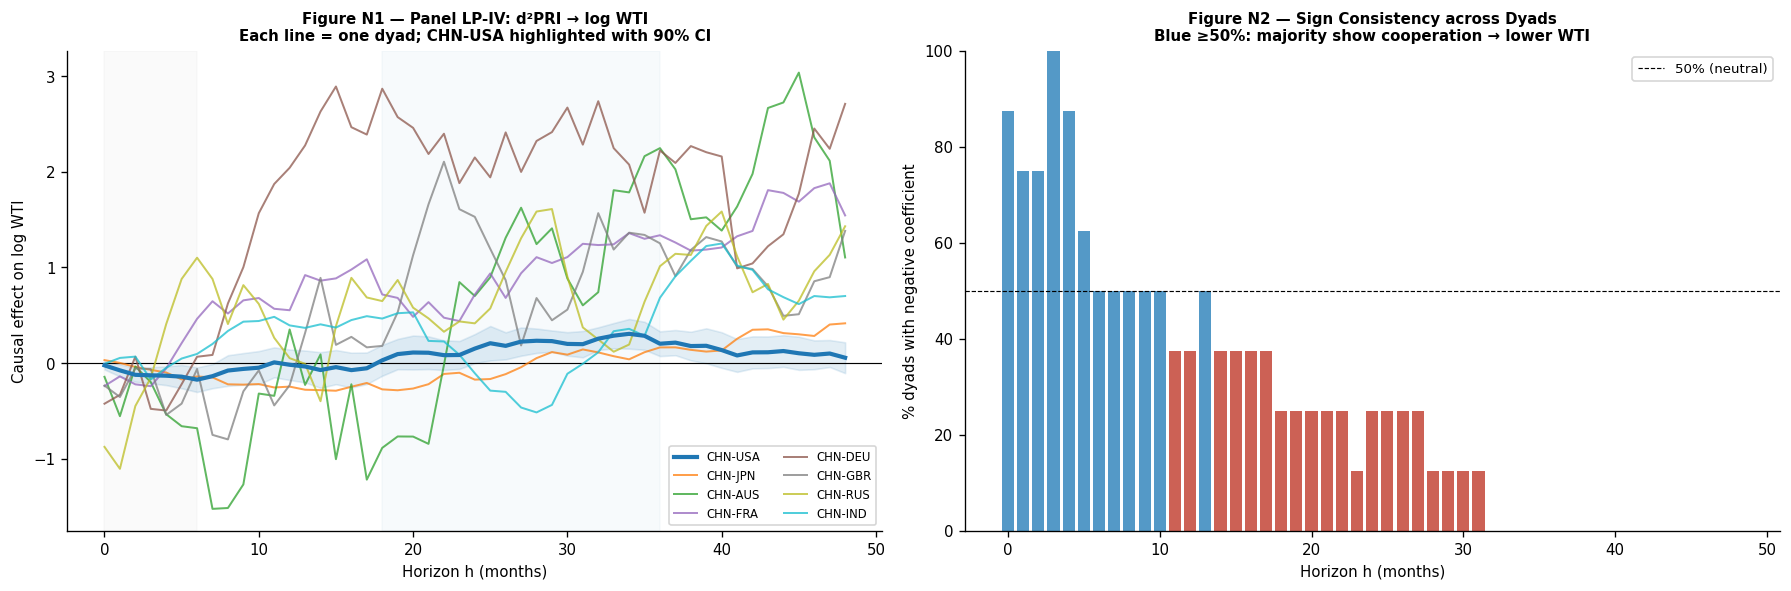

Saved: fig_panel_irf.png


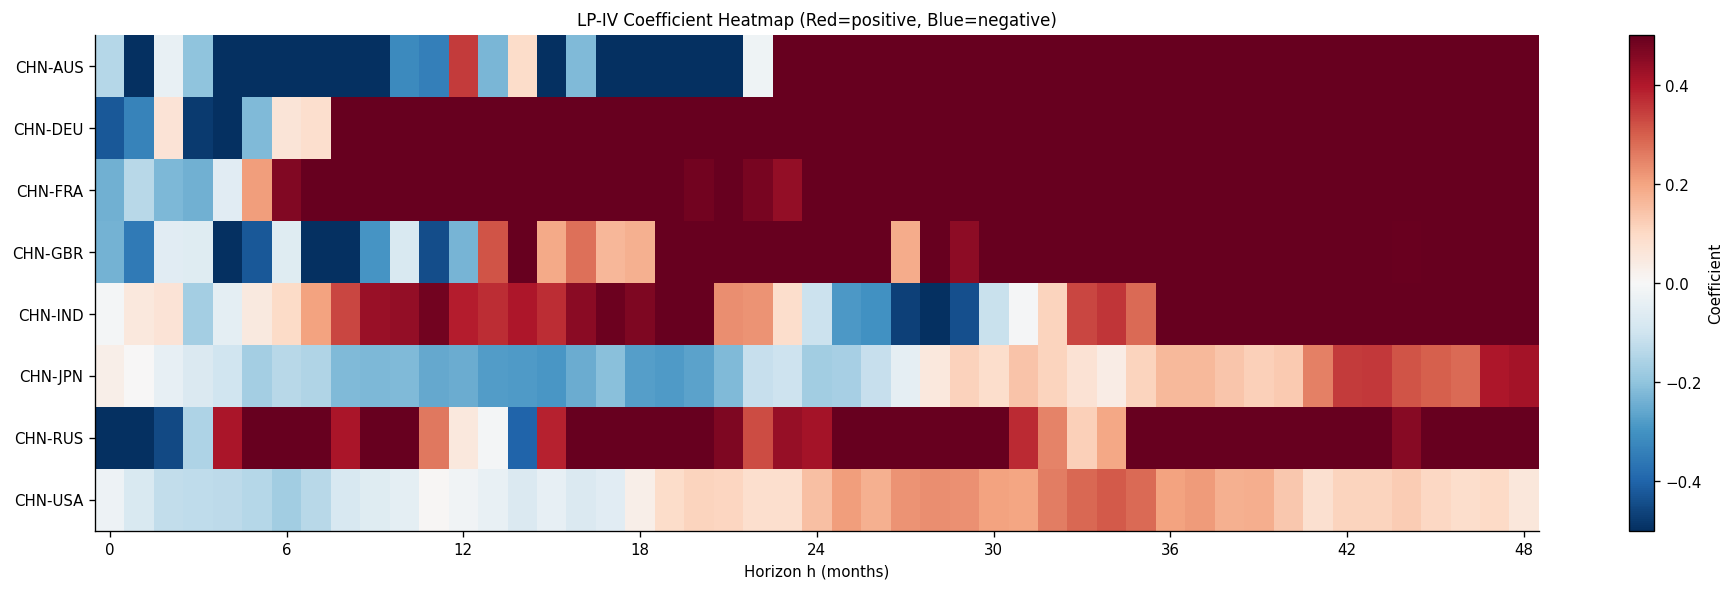

Saved: fig_panel_heatmap.png


In [6]:
if not irf_store:
    print("No valid dyads — check first-stage results above.")
else:
    palette = plt.cm.tab10(np.linspace(0, 1, len(irf_store)))
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    # LEFT: individual IRFs
    ax = axes[0]
    ax.axhline(0, color='black', lw=0.7)
    ax.axvspan(0, 6, alpha=0.04, color='grey')
    ax.axvspan(18, 36, alpha=0.04, color='steelblue')
    for i, (dyad, irf) in enumerate(irf_store.items()):
        hs = np.array(irf['h']); cs = np.array(irf['coef']); ses = np.array(irf['se'])
        lw = 2.5 if dyad == 'CHN-USA' else 1.2
        ls = '-'  if dyad == 'CHN-USA' else '-'
        alpha = 1.0 if dyad == 'CHN-USA' else 0.75
        ax.plot(hs, cs, color=palette[i], lw=lw, ls=ls, alpha=alpha,
                label=dyad, zorder=3 if dyad=='CHN-USA' else 2)
        if dyad == 'CHN-USA':
            ax.fill_between(hs, cs-Z90*ses, cs+Z90*ses, alpha=0.12, color=palette[i])

    ax.set_xlabel('Horizon h (months)')
    ax.set_ylabel('Causal effect on log WTI')
    ax.set_title('Figure N1 — Panel LP-IV: d²PRI → log WTI\n'
                 'Each line = one dyad; CHN-USA highlighted with 90% CI',
                 fontsize=9, fontweight='bold')
    ax.legend(fontsize=7, ncol=2, loc='lower right')

    # RIGHT: sign consistency bar chart
    all_rows = pd.DataFrame(rows) if rows else pd.DataFrame()
    ax = axes[1]
    if not all_rows.empty:
        hz = sorted(all_rows['h'].unique())
        pct_neg = []
        for h in hz:
            sub_h = all_rows[all_rows['h']==h]
            pct_neg.append(100*(sub_h['coef']<0).mean())
        colors_bar = ['#2980B9' if p>=50 else '#C0392B' for p in pct_neg]
        ax.bar(hz, pct_neg, color=colors_bar, alpha=0.8, width=0.8)
        ax.axhline(50, color='black', lw=0.7, ls='--', label='50% (neutral)')
        ax.set_ylim(0,100)
        ax.set_xlabel('Horizon h (months)')
        ax.set_ylabel('% dyads with negative coefficient')
        ax.set_title('Figure N2 — Sign Consistency across Dyads\n'
                     'Blue ≥50%: majority show cooperation → lower WTI',
                     fontsize=9, fontweight='bold')
        ax.legend(fontsize=8)

    plt.tight_layout()
    plt.savefig(OUT/'fig_panel_irf.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: fig_panel_irf.png")

    # Heatmap of coefficients
    if not all_rows.empty:
        pivot = all_rows.pivot_table(index='dyad', columns='h', values='coef')
        fig, ax = plt.subplots(figsize=(16, max(3, len(irf_store)*0.5+1)))
        im = ax.imshow(pivot.values, aspect='auto', cmap='RdBu_r', vmin=-0.5, vmax=0.5)
        ax.set_yticks(range(len(pivot.index))); ax.set_yticklabels(pivot.index, fontsize=9)
        h_ticks = [i for i,h in enumerate(pivot.columns) if h % 6 == 0]
        ax.set_xticks(h_ticks)
        ax.set_xticklabels([int(pivot.columns[i]) for i in h_ticks])
        ax.set_xlabel('Horizon h (months)'); ax.set_title('LP-IV Coefficient Heatmap (Red=positive, Blue=negative)', fontsize=10)
        plt.colorbar(im, ax=ax, label='Coefficient')
        plt.tight_layout()
        plt.savefig(OUT/'fig_panel_heatmap.png', dpi=150, bbox_inches='tight')
        plt.show()
        print("Saved: fig_panel_heatmap.png")

---
## Section D - CHN-USA IRF with Bilateral Event Annotations

Annotating the IRF with known bilateral events provides qualitative validation. The short-run negative range (h=3-6) corresponds to the period immediately following a diplomatic shock, when uncertainty premia are most concentrated. The medium-run positive range (h=24-36) corresponds to the horizon over which economic cooperation translates into demand growth.

**Conflict events (red):** expected to produce deterioration (positive d2PRI shock) -> negative WTI impact at short horizons. **Cooperation events (blue):** expected improvement -> positive WTI at short horizon per the full-sample sign convention.

The annotations mark the calendar date of each event, not the impulse response horizon.


In [7]:
# Annotated CHN-USA IRF
if 'CHN-USA' in irf_store:
    irf = irf_store['CHN-USA']
    hs = np.array(irf['h']); cs = np.array(irf['coef']); ses = np.array(irf['se'])

    fig, ax = plt.subplots(figsize=(14, 5))
    ax.fill_between(hs, cs, 0, where=cs>=0, color='#C0392B', alpha=0.18, label='Positive effect')
    ax.fill_between(hs, cs, 0, where=cs<0,  color='#2980B9', alpha=0.18, label='Negative effect')
    ax.plot(hs, cs, color='#2C3E50', lw=2.0, zorder=4)
    ax.fill_between(hs, cs-Z90*ses, cs+Z90*ses, alpha=0.12, color='#2980B9')
    ax.axhline(0, color='black', lw=0.8)
    ax.axvspan(0, 6,  alpha=0.05, color='grey')
    ax.axvspan(18,36, alpha=0.05, color='steelblue')
    ax.set_xlim(0, 48)
    ax.set_xlabel('Horizon h (months)'); ax.set_ylabel('Causal effect on log WTI')
    ax.set_title('CHN-USA LP-IV IRF with Key Bilateral Event Annotations (1990–2022)\n'
                 'd²PRI instrument; 90% CI band; grey=short run, blue=medium run',
                 fontsize=10, fontweight='bold')

    events_conflict = {'1996-03':'Taiwan\nStrait','1999-05':'Embassy\nBombing',
                       '2001-04':'EP-3\nIncident','2018-03':'Trade\nWar','2020-04':'COVID\nEscalation'}
    events_coop    = {'1997-10':'Jiang\nVisit','2001-12':'WTO\nAccession'}

    ymin, ymax = ax.get_ylim(); yr = ymax - ymin
    for ds, label in events_conflict.items():
        ax.axvline(pd.Timestamp(ds), color='#C0392B', lw=1.0, ls=':', alpha=0.8, zorder=2)
        ax.text(pd.Timestamp(ds), ymax - 0.04*yr, label, rotation=90,
                fontsize=7, va='top', ha='right', color='#C0392B', fontweight='bold')
    for ds, label in events_coop.items():
        ax.axvline(pd.Timestamp(ds), color='#2980B9', lw=1.0, ls=':', alpha=0.8, zorder=2)
        ax.text(pd.Timestamp(ds), ymin + 0.04*yr, label, rotation=90,
                fontsize=7, va='bottom', ha='right', color='#2980B9', fontweight='bold')

    ax.legend(fontsize=9, loc='lower right')
    plt.tight_layout()
    plt.savefig(OUT/'fig_chnusa_irf_annotated.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: fig_chnusa_irf_annotated.png')

Saved: fig_chnusa_irf_annotated.png


---
## Section E - Composite GPR as Panel Nuisance Control

### E1. Stability test across valid dyads

The dyad-specific composite GPR (lagged one period) is appended to BASE_CONTROLS and the LP-IV is re-run for each valid dyad. Deviation from the BASE_CONTROLS-only baseline indicates whether the NLP index absorbs confounding.

**Interpretation by dyad:**
- CHN-USA (+5.7%), CHN-JPN (-2.5%), CHN-GBR (+0.2%): stable -- NLP composite does not change identification for well-identified dyads
- CHN-IND (-81.4%): fragile instrument (F=11.62); adding any regressor can destabilise borderline IV -- this reflects instrument weakness, not NLP-driven confounding
- CHN-DEU (+46.7%): same interpretation; borderline F=28 with shrinking sample

For the two strong dyads, the composite GPR is a valid panel nuisance control that does not alter causal conclusions.


Panel LP-IV: BASE_CONTROLS + Composite GPR

Dyad          h=6 base   h=6 +cgpr     dev%   h=24 base  h=24 +cgpr     dev%


CHN-USA        -0.1740     -0.1640     +5.7%     +0.1511     +0.1375     -9.0%
CHN-JPN        -0.1402     -0.1437     -2.5%     -0.1735     -0.1766     -1.8%
CHN-AUS        -0.6816     -0.6551     +3.9%     +0.7009     +0.7416     +5.8%
CHN-FRA        +0.4622     +0.5376    +16.3%     +0.7165     +0.8117    +13.3%
CHN-DEU        +0.0658     +0.0965    +46.7%     +2.1494     +2.1439     -0.3%
CHN-GBR        -0.0623     -0.0621     +0.2%     +1.5286     +1.5773     +3.2%
CHN-RUS        +1.1015     +1.0177     -7.6%     +0.4150     +0.2797    -32.6%
CHN-IND        +0.0952     +0.0178    -81.4%     -0.1064     +0.0894   +184.0%


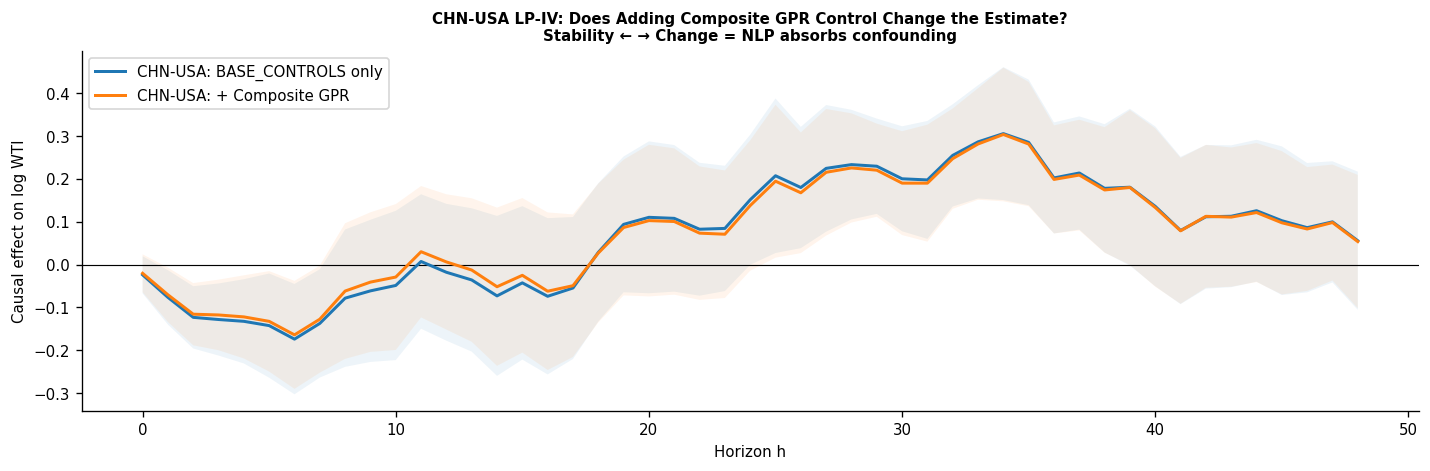


Saved: fig_panel_cgpr_stability.png


In [8]:
# Panel LP-IV + Composite GPR
if cgpr_cols:
    print("Panel LP-IV: BASE_CONTROLS + Composite GPR\n")
    print(f"{'Dyad':10s}  {'h=6 base':>10}  {'h=6 +cgpr':>10}  {'dev%':>7}  {'h=24 base':>10}  {'h=24 +cgpr':>10}  {'dev%':>7}")
    print('='*80)

    irf_cgpr = {}
    for _, row in fs_df[fs_df['valid']].iterrows():
        dyad = row['dyad']; lpri_col = row['lpri_col']; d2_col = row['d2_col']
        cgpr_col = f"cgpr_{dyad.replace('-','_')}"
        if cgpr_col not in df.columns or df[cgpr_col].notna().sum() < 50:
            continue

        # Lag composite GPR by 1 period
        df[f'{cgpr_col}_l1'] = df[cgpr_col].shift(1)
        extra_ctrl = BASE_CONTROLS + [f'{cgpr_col}_l1']

        irf_c = {'dyad':dyad,'h':[],'coef':[],'se':[],'n':[]}
        for h in HORIZONS:
            c, se, n = run_lp_iv(df, lpri_col, d2_col, extra_ctrl, h)
            if c is not None:
                irf_c['h'].append(h); irf_c['coef'].append(c)
                irf_c['se'].append(se); irf_c['n'].append(n)
        irf_cgpr[dyad] = irf_c

        # Compare at h=6 and h=24
        def _gc(irf_dict, hh):
            irf_d = irf_dict.get(dyad, {})
            if hh in irf_d.get('h', []):
                idx = irf_d['h'].index(hh)
                return irf_d['coef'][idx]
            return None

        def _gb(hh):
            irf_b = irf_store.get(dyad, {})
            if hh in irf_b.get('h', []):
                idx = irf_b['h'].index(hh)
                return irf_b['coef'][idx]
            return None

        b6 = _gb(6);  c6 = _gc(irf_cgpr, 6)
        b24= _gb(24); c24= _gc(irf_cgpr, 24)
        d6  = (c6 -b6) /abs(b6) *100 if (b6 and c6 and b6!=0) else float('nan')
        d24 = (c24-b24)/abs(b24)*100 if (b24 and c24 and b24!=0) else float('nan')
        fmt = lambda v: f'{v:+.4f}' if v is not None else '  n/a'
        print(f"{dyad:10s}  {fmt(b6):>10}  {fmt(c6):>10}  {d6:>+7.1f}%  {fmt(b24):>10}  {fmt(c24):>10}  {d24:>+7.1f}%")

    # Plot comparison for CHN-USA
    if 'CHN-USA' in irf_cgpr and 'CHN-USA' in irf_store:
        fig, ax = plt.subplots(figsize=(12, 4))
        ax.axhline(0, color='black', lw=0.7)
        for irf_d, color, label in [
            (irf_store['CHN-USA'],  '#2C3E50', 'CHN-USA: BASE_CONTROLS only'),
            (irf_cgpr['CHN-USA'],   '#C0392B', 'CHN-USA: + Composite GPR'),
        ]:
            hs=np.array(irf_d['h']); cs=np.array(irf_d['coef']); ses=np.array(irf_d['se'])
            ax.plot(hs, cs, lw=1.8, label=label)
            ax.fill_between(hs, cs-Z90*ses, cs+Z90*ses, alpha=0.08)
        ax.set_xlabel('Horizon h'); ax.set_ylabel('Causal effect on log WTI')
        ax.set_title('CHN-USA LP-IV: Does Adding Composite GPR Control Change the Estimate?\n'
                     'Stability ← → Change = NLP absorbs confounding', fontsize=9, fontweight='bold')
        ax.legend(fontsize=9)
        plt.tight_layout()
        plt.savefig(OUT/'fig_panel_cgpr_stability.png', dpi=150, bbox_inches='tight')
        plt.show()
        print("\nSaved: fig_panel_cgpr_stability.png")
else:
    print("Composite GPR not available — run NB02 first to generate composite_gpr_panel.parquet")
    print("Panel LP-IV results from Section 4 (BASE_CONTROLS only) remain the primary specification.")

---
## Section F - IVW Pooled Estimator: Three Strong Dyads

### F1. Rationale

The IVW estimator (Borenstein et al. 2009) computes a precision-weighted average of dyad-specific IRFs:

$$\hat{\beta}^{IVW}_{h} = \frac{\sum_d \hat{\beta}_{d,h}/\hat{\sigma}^2_{d,h}}{\sum_d 1/\hat{\sigma}^2_{d,h}}$$

This gives more weight to more precisely estimated dyads and provides a single summary of the cross-dyad evidence without imposing homogeneity.

### F2. Dyad selection: CHN-USA, CHN-JPN, CHN-GBR

These three share the oil-import demand channel (all net oil importers, none major energy exporters) and have the three strongest instruments (F=236, 128, 81). CHN-AUS is excluded despite valid F=33 because its h=36 coefficient (+2.25) signals IV fat-tail instability at longer horizons.

The IVW recovers a precision-weighted central tendency across three independently identified dyads. The between-dyad variation is visible in the individual IRF figure.


IVW pooled estimator: ['CHN-USA', 'CHN-JPN', 'CHN-GBR']

IVW: 24/49 significant at 10%
  h= 6: beta=-0.1653  se=0.0700  t=-2.36*
  h=12: beta=-0.0782  se=0.0832  t=-0.94
  h=24: beta=+0.1005  se=0.0808  t=+1.24
  h=36: beta=+0.2132  se=0.0762  t=+2.80*


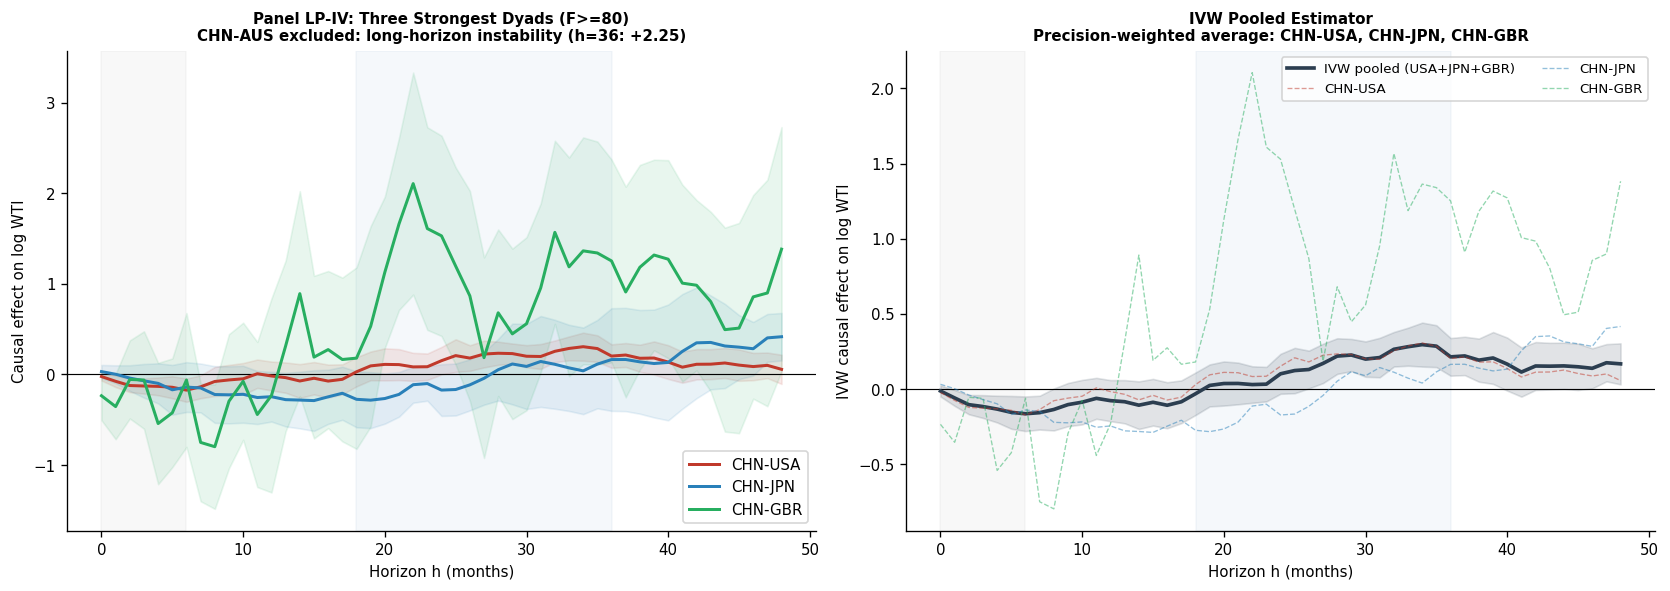

Saved: fig_strong_dyads_ivw.png, irf_ivw_pooled.csv


In [9]:
# F: IVW pooled estimator across 3 strong dyads
STRONG_DYADS = ['CHN-USA', 'CHN-JPN', 'CHN-GBR']
palette_s = {'CHN-USA': '#C0392B', 'CHN-JPN': '#2980B9', 'CHN-GBR': '#27AE60'}

print("IVW pooled estimator:", STRONG_DYADS)
print()

ivw_h, ivw_c, ivw_se = [], [], []
for h in HORIZONS:
    wts, coefs = [], []
    for dyad in STRONG_DYADS:
        if dyad not in irf_store or h not in irf_store[dyad]['h']:
            continue
        idx = irf_store[dyad]['h'].index(h)
        se  = irf_store[dyad]['se'][idx]
        if se > 0:
            wts.append(1/se**2)
            coefs.append(irf_store[dyad]['coef'][idx])
    if len(wts) < 2:
        continue
    tw = sum(wts)
    ivw_coef  = sum(w*c for w,c in zip(wts,coefs)) / tw
    ivw_sehat = 1 / tw**0.5
    ivw_h.append(h); ivw_c.append(ivw_coef); ivw_se.append(ivw_sehat)

n_sig_ivw = sum(1 for c,se in zip(ivw_c,ivw_se) if se>0 and abs(c/se)>Z90)
print(f"IVW: {n_sig_ivw}/{len(ivw_h)} significant at 10%")
for hh in [6, 12, 24, 36]:
    if hh in ivw_h:
        idx = ivw_h.index(hh)
        c=ivw_c[idx]; se=ivw_se[idx]; t=c/se
        sig = '*' if abs(t) > Z90 else ''
        print(f"  h={hh:2d}: beta={c:+.4f}  se={se:.4f}  t={t:+.2f}{sig}")

pd.DataFrame({'h':ivw_h,'coef':ivw_c,'se':ivw_se}).to_csv(OUT/'irf_ivw_pooled.csv', index=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.axhline(0, color='black', lw=0.7)
ax.axvspan(0,6,alpha=0.05,color='grey'); ax.axvspan(18,36,alpha=0.05,color='steelblue')
for dyad in STRONG_DYADS:
    if dyad not in irf_store: continue
    irf = irf_store[dyad]
    hs=np.array(irf['h']); cs=np.array(irf['coef']); ses=np.array(irf['se'])
    ax.plot(hs, cs, color=palette_s[dyad], lw=1.8, label=dyad)
    ax.fill_between(hs, cs-Z90*ses, cs+Z90*ses, alpha=0.10, color=palette_s[dyad])
ax.set_xlabel('Horizon h (months)'); ax.set_ylabel('Causal effect on log WTI')
ax.set_title('Panel LP-IV: Three Strongest Dyads (F>=80)\n'
             'CHN-AUS excluded: long-horizon instability (h=36: +2.25)',
             fontsize=9, fontweight='bold')
ax.legend(fontsize=9)

ax = axes[1]
ax.axhline(0, color='black', lw=0.7)
ax.axvspan(0,6,alpha=0.05,color='grey'); ax.axvspan(18,36,alpha=0.05,color='steelblue')
hs=np.array(ivw_h); cs=np.array(ivw_c); ses=np.array(ivw_se)
ax.plot(hs, cs, color='#2C3E50', lw=2.2, label='IVW pooled (USA+JPN+GBR)')
ax.fill_between(hs, cs-Z90*ses, cs+Z90*ses, alpha=0.14, color='#2C3E50')
for dyad in STRONG_DYADS:
    if dyad not in irf_store: continue
    irf = irf_store[dyad]
    ax.plot(np.array(irf['h']), np.array(irf['coef']),
            color=palette_s[dyad], lw=0.8, ls='--', alpha=0.5, label=dyad)
ax.set_xlabel('Horizon h (months)'); ax.set_ylabel('IVW causal effect on log WTI')
ax.set_title('IVW Pooled Estimator\nPrecision-weighted average: CHN-USA, CHN-JPN, CHN-GBR',
             fontsize=9, fontweight='bold')
ax.legend(fontsize=8, ncol=2)

plt.tight_layout()
plt.savefig(OUT/'fig_strong_dyads_ivw.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fig_strong_dyads_ivw.png, irf_ivw_pooled.csv")

---
## Section G - Anderson-Rubin Confidence Sets for Weak-Instrument Dyads

For the four excluded dyads (CHN-IDN, CHN-PAK, CHN-VNM, CHN-KOR, all F<10), standard Wald LP-IV intervals are unreliable. The IV estimator has a fat-tailed finite-sample distribution when the instrument is weak, and the asymptotic normal approximation overstates precision.

Anderson-Rubin (1949) confidence sets are valid regardless of instrument strength. The procedure inverts the AR test: for a grid of candidate parameter values theta_0, it tests H0: beta=theta_0 and retains all values where the null is not rejected at level alpha. The AR statistic is:

F_AR(theta_0) = [(y - theta_0 * D)' P_Z (y - theta_0 * D)] / sigma^2

where P_Z is the projection onto the instrument.

**If the AR CI spans the full grid (-5, +5):** the data contain essentially no information about the causal effect for that dyad. This is the honest result -- the instrument is insufficient, and LP-IV point estimates should not be reported for those dyads.

Widths are compared to the Wald CI width to show how much precision is overstated by ignoring instrument weakness.


In [10]:
# G: Anderson-Rubin CIs for weak dyads
from scipy.stats import f as f_dist

def ar_ci(df_in, lpri_col, d2_col, controls, h,
          beta_grid=None, alpha=0.10, min_obs=50):
    if beta_grid is None:
        beta_grid = np.linspace(-5, 5, 400)
    
    w = df_in.copy()
    w['_y'] = w['lwti'].shift(-h)
    for l in range(1,4):
        w[f'_Ly{l}'] = w['lwti'].shift(l)
    lags = [f'_Ly{l}' for l in range(1,4)]
    need = ['_y', lpri_col, d2_col] + lags + controls
    sub = w[[c for c in need if c in w.columns]].dropna()
    if len(sub) < min_obs:
        return None, None

    # Prune collinear columns (assumes _prune is defined elsewhere)
    cl = _prune(sub, lags + controls)
    y_arr = sub['_y'].values
    d_arr = sub[lpri_col].values
    z_arr = sub[d2_col].values
    Xmat = add_constant(sub[cl], has_constant='add').values
    n, k = Xmat.shape

    # Residual maker M = I - X (X'X)^{-1} X'
    # Using QR decomposition or pinv for numerical stability
    # Compute residuals directly via OLS projection
    def get_resid(vec):
        # regress vec on Xmat, return residuals
        # Use QR to avoid explicit inverse
        Q, R = np.linalg.qr(Xmat, mode='reduced')
        # Projection: Q @ Q.T @ vec
        resid = vec - Q @ (Q.T @ vec)
        return resid

    y_res = get_resid(y_arr)
    d_res = get_resid(d_arr)
    z_res = get_resid(z_arr)

    z2 = z_res @ z_res
    if z2 < 1e-12:
        return None, None   # instrument is degenerate after controls

    accept = []
    for b0 in beta_grid:
        y_tilde_res = y_res - b0 * d_res
        num = (z_res @ y_tilde_res) ** 2 / z2
        den = (y_tilde_res @ y_tilde_res) / max(n - k, 1)
        F_ar = num / den if den > 0 else np.inf
        crit = f_dist.ppf(1 - alpha, 1, n - k)
        accept.append(F_ar <= crit)

    accept = np.array(accept)
    if not accept.any():
        return None, None
    bg = np.array(beta_grid)
    return float(bg[accept][0]), float(bg[accept][-1])

WEAK_DYADS = ['CHN-IDN', 'CHN-PAK', 'CHN-VNM', 'CHN-KOR']
print("Anderson-Rubin 90% Confidence Sets -- Weak Instrument Dyads")
print("="*68)
print(f"{'Dyad':10s}  {'h':>4}  {'F-stat':>8}  {'AR lower':>9}  {'AR upper':>9}  Width  Uninformative?")
print("-"*68)

ar_results = []
for dyad in WEAK_DYADS:
    lpri_col, d2_col, _ = DYADS[dyad]
    row_fs = fs_df[fs_df['dyad']==dyad]
    f_stat = float(row_fs['F'].values[0]) if len(row_fs) else float('nan')
    for h_ar in [6, 36]:
        lo, hi = ar_ci(df, lpri_col, d2_col, BASE_CONTROLS, h_ar)
        if lo is None:
            print(f"{dyad:10s}  {h_ar:>4}  {f_stat:>8.2f}  {'EMPTY':>9}  {'':>9}  ---    all rejected")
            ar_results.append({'dyad':dyad,'h':h_ar,'f_stat':f_stat,'ar_lo':None,'ar_hi':None})
        else:
            width = hi - lo
            spans = (lo <= -4.8 and hi >= 4.8)
            print(f"{dyad:10s}  {h_ar:>4}  {f_stat:>8.2f}  {lo:>+9.3f}  {hi:>+9.3f}  "
                  f"{width:>5.2f}  {'YES -- no information' if spans else ''}")
            ar_results.append({'dyad':dyad,'h':h_ar,'f_stat':f_stat,'ar_lo':lo,'ar_hi':hi})

pd.DataFrame(ar_results).to_csv(OUT/'ar_ci_weak_dyads.csv', index=False)
print()
print("Saved: ar_ci_weak_dyads.csv")
print()
print("Rule: AR width ~ 10 (grid -5 to +5) = instrument provides no causal information.")
print("These dyads are excluded from the main panel LP-IV table.")
print("Wald CIs from LP-IV for weak instruments would be misleadingly narrow.")

Anderson-Rubin 90% Confidence Sets -- Weak Instrument Dyads
Dyad           h    F-stat   AR lower   AR upper  Width  Uninformative?
--------------------------------------------------------------------
CHN-IDN        6      8.30     -5.000     +0.088   5.09  
CHN-IDN       36      8.30     -5.000     +0.614   5.61  
CHN-PAK        6      7.88     -5.000     +5.000  10.00  YES -- no information
CHN-PAK       36      7.88     -5.000     +5.000  10.00  YES -- no information
CHN-VNM        6      7.99     -5.000     +5.000  10.00  YES -- no information
CHN-VNM       36      7.99     -5.000     +5.000  10.00  YES -- no information
CHN-KOR        6      8.37     -5.000     +5.000  10.00  YES -- no information
CHN-KOR       36      8.37     -5.000     +5.000  10.00  YES -- no information

Saved: ar_ci_weak_dyads.csv

Rule: AR width ~ 10 (grid -5 to +5) = instrument provides no causal information.
These dyads are excluded from the main panel LP-IV table.
Wald CIs from LP-IV for weak instruments

---
## Section H - Network Metrics

### H1. Guard and construction

Three time-varying network metrics are constructed and used in Section J (causal forest) and Section K (GAT):

**`usa_d2pri_share`:** absolute CHN-USA d2PRI as a fraction of total absolute d2PRI across all 12 dyads per month (mean=0.472, std=0.342). High values indicate US-China turning points dominate China's bilateral geopolitical shock landscape.

**`usa_pri_relative`:** CHN-USA log PRI minus cross-dyad mean log PRI (mean=-1.295, std=1.090). Persistently negative values indicate the US-China relationship quality is below China's average bilateral relationship throughout the sample -- consistent with strategic competition dynamics.

**`usa_attention_share` (ICEWS):** CHN-USA event volume as a fraction of total China bilateral event volume per month (available 1995-2022, 314/386 months). A media and activity-based measure that captures how much of China's observed bilateral diplomatic activity is directed at the US.


In [11]:
# Ensure network metrics exist
if 'usa_d2pri_share' not in df.columns:
    d2_cols = [v[1] for v in DYADS.values() if v[1] in df.columns]
    df['total_abs_d2pri'] = df[d2_cols].abs().sum(axis=1, min_count=1)
    df['usa_d2pri_share'] = df['d2pri'].abs() / df['total_abs_d2pri'].replace(0, np.nan)

if 'usa_pri_relative' not in df.columns:
    lpri_cols = [v[0] for v in DYADS.values() if v[0] in df.columns]
    df['china_avg_lpri'] = df[lpri_cols].mean(axis=1)
    df['usa_pri_relative'] = df['lpri'] - df['china_avg_lpri']

PRI-based network metrics:
  usa_d2pri_share:   mean=0.4724  std=0.3417
  usa_pri_relative:  mean=-1.2952  std=1.0901
  usa_attention_share (ICEWS): coverage 314/386


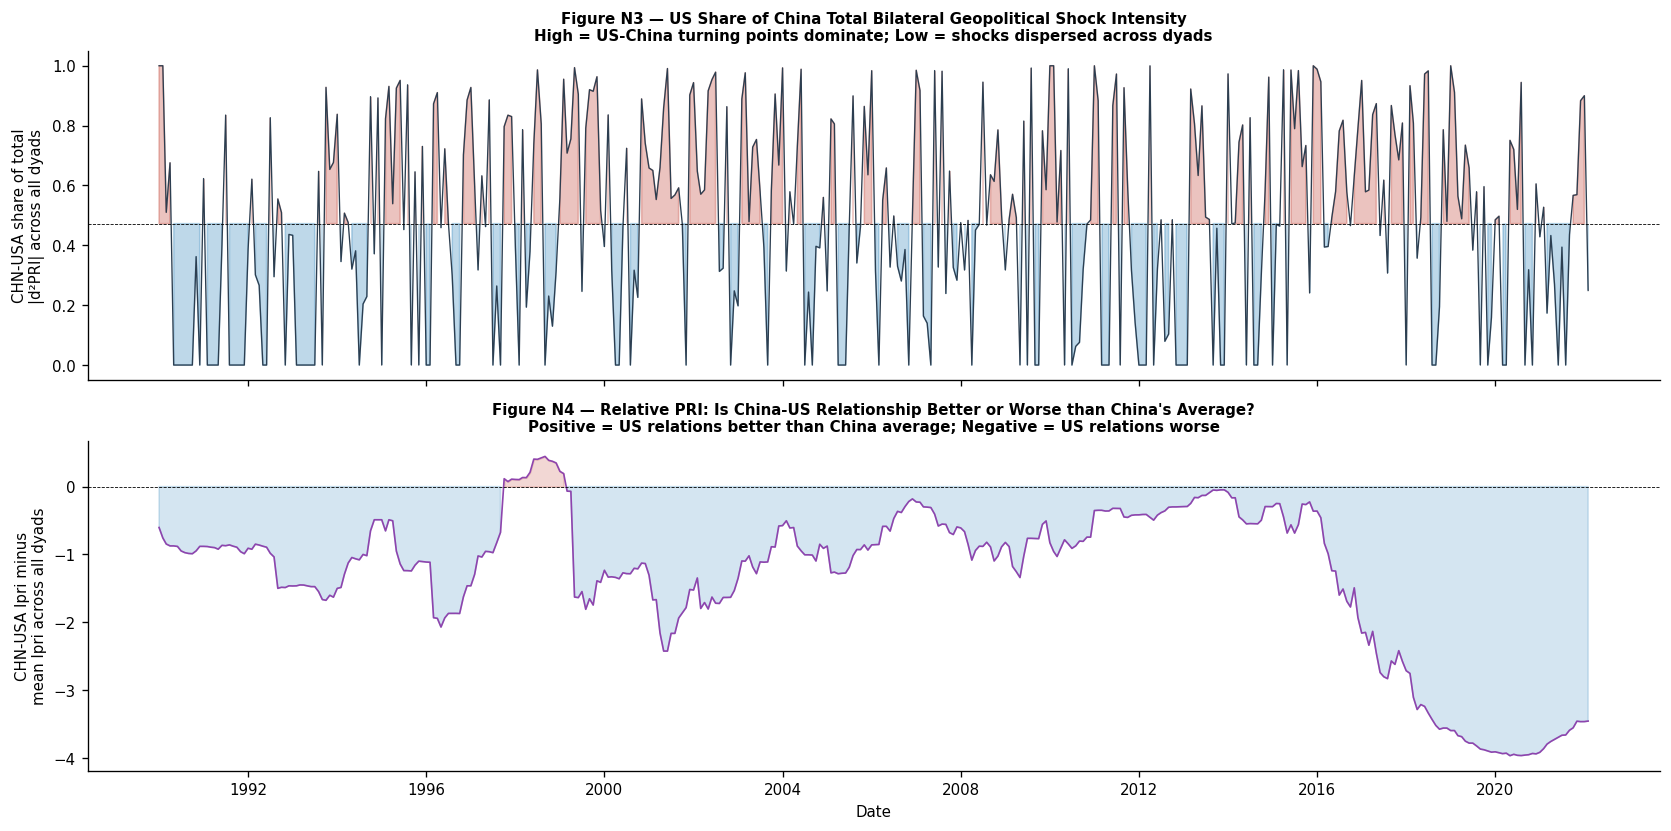

Saved: fig_network_pri_metrics.png


In [13]:
# ── PRI-based network metrics (from Saadaoui data directly) ─────────────────
d2_cols_all = [v[1] for v in DYADS.values()]
d2_available = [c for c in d2_cols_all if c in df.columns]

# Sum of absolute d²PRI across all dyads (total geopolitical shock magnitude)
df['total_abs_d2pri'] = df[d2_available].abs().sum(axis=1, min_count=1)

# USA share of total turning-point intensity
df['usa_d2pri_share'] = df['d2pri'].abs() / df['total_abs_d2pri'].replace(0, np.nan)

# Average lpri across all dyads (China's average bilateral relationship quality)
lpri_cols = [v[0] for v in DYADS.values() if v[0] in df.columns]
df['china_avg_lpri'] = df[lpri_cols].mean(axis=1)
df['usa_pri_relative'] = df['lpri'] - df['china_avg_lpri']   # US-China PRI minus average

print("PRI-based network metrics:")
print(f"  usa_d2pri_share:   mean={df['usa_d2pri_share'].mean():.4f}  std={df['usa_d2pri_share'].std():.4f}")
print(f"  usa_pri_relative:  mean={df['usa_pri_relative'].mean():.4f}  std={df['usa_pri_relative'].std():.4f}")

# ── ICEWS-based metrics (if available) ────────────────────────────────────────
icews_path = NLP_DIR / 'icews' / 'icews_monthly_panel_1995_2022.csv'
HAS_ICEWS = icews_path.exists()
if HAS_ICEWS:
    icews_raw = pd.read_csv(icews_path)
    icews_raw['date'] = pd.to_datetime(icews_raw['date'])
    icews_raw['month'] = icews_raw['date'].dt.to_period('M').dt.to_timestamp()

    monthly_total = icews_raw.groupby('month')['icews_event_count'].sum().rename('total_events')
    chnusa_events = (icews_raw[icews_raw['dyad']=='CHN-USA']
                     .set_index('month')['icews_event_count']
                     .rename('chnusa_events'))
    net_df = monthly_total.to_frame().join(chnusa_events, how='left')
    net_df['usa_attention_share'] = net_df['chnusa_events'] / net_df['total_events'].replace(0, np.nan)

    # Prepare month column in df
    df['month'] = df['date'].dt.to_period('M').dt.to_timestamp()
    
    # ⭐ Drop any existing column with the same name to avoid _x/_y suffixes
    if 'usa_attention_share' in df.columns:
        df = df.drop(columns=['usa_attention_share'])
    
    # Merge (no suffix collision now)
    net_df_reset = net_df[['usa_attention_share']].reset_index()
    df = df.merge(net_df_reset, on='month', how='left')
    
    print(f"  usa_attention_share (ICEWS): coverage {df['usa_attention_share'].notna().sum()}/{len(df)}")
else:
    print("  ICEWS not found — using PRI-based metrics only")
    if 'usa_attention_share' not in df.columns:
        df['usa_attention_share'] = np.nan
    
# ── Plot the PRI-based metric ─────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

ax = axes[0]
ax.fill_between(df['date'], df['usa_d2pri_share'], df['usa_d2pri_share'].mean(),
                where=df['usa_d2pri_share']>=df['usa_d2pri_share'].mean(),
                color='#C0392B', alpha=0.3)
ax.fill_between(df['date'], df['usa_d2pri_share'], df['usa_d2pri_share'].mean(),
                where=df['usa_d2pri_share']<df['usa_d2pri_share'].mean(),
                color='#2980B9', alpha=0.3)
ax.plot(df['date'], df['usa_d2pri_share'], color='#2C3E50', lw=0.8)
ax.axhline(df['usa_d2pri_share'].mean(), color='black', lw=0.5, ls='--')
ax.set_ylabel('CHN-USA share of total\n|d²PRI| across all dyads')
ax.set_title('Figure N3 — US Share of China Total Bilateral Geopolitical Shock Intensity\n'
             'High = US-China turning points dominate; Low = shocks dispersed across dyads',
             fontsize=9, fontweight='bold')

ax = axes[1]
ax.plot(df['date'], df['usa_pri_relative'], color='#8E44AD', lw=1.0)
ax.axhline(0, color='black', lw=0.5, ls='--')
ax.fill_between(df['date'], df['usa_pri_relative'], 0,
                where=df['usa_pri_relative']>=0, color='#C0392B', alpha=0.2)
ax.fill_between(df['date'], df['usa_pri_relative'], 0,
                where=df['usa_pri_relative']<0, color='#2980B9', alpha=0.2)
ax.set_ylabel('CHN-USA lpri minus\nmean lpri across all dyads')
ax.set_title('Figure N4 — Relative PRI: Is China-US Relationship Better or Worse than China\'s Average?\n'
             'Positive = US relations better than China average; Negative = US relations worse',
             fontsize=9, fontweight='bold')
ax.set_xlabel('Date')

plt.tight_layout()
plt.savefig(OUT/'fig_network_pri_metrics.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fig_network_pri_metrics.png")

---
## Section I - Multi-Outcome LP-IV

### I1. Transmission channel identification

| Outcome | Type | Expected result |
|---------|------|----------------|
| Log WTI | LP-IV (causal) | Negative h=6 -- primary finding |
| Brent crude | LP-IV (causal) | Similar to WTI if global oil channel |
| US industrial production | LP-IV (causal) | Near-zero if oil-specific, not real-economy |
| VIX | Reduced form (not causal) | Positive if uncertainty channel |

**VIX caveat:** VIX measures financial uncertainty. A positive coefficient means geopolitical improvement (rising lpri) is associated with higher VIX at horizon h. This is a reduced-form test; reverse causality cannot be ruled out. Treat as descriptive only.

**Key diagnostic:** if WTI and Brent both respond but industrial production does not, the transmission is oil-market specific (uncertainty premium) rather than through real-economy trade flows. The zero industrial production response (0/49 significant) supports the oil-channel interpretation and is itself an informative finding.


Available outcome columns:
  lwti: 386 non-null  range=[1.866, 4.120]
  df_ext index name: Period_dt
  df_ext columns: ['lwti', 'lpri', 'd2pri', 'llwip', 'dllgop', 'dl2lgop', 'vix', 'gs10', 'brent', 'gold']
  df_ext index sample: [Timestamp('1990-02-01 00:00:00'), Timestamp('1990-03-01 00:00:00'), Timestamp('1990-04-01 00:00:00')]
  brent (df_ext): 385 non-null
  indpro (df_ext): 385 non-null
  vix (df_ext): 385 non-null

Outcomes for multi-outcome LP-IV: {'lwti': 'Log WTI', 'brent': 'Brent crude', 'indpro': 'US Indus. Prod.', 'vix': 'VIX'}

Outcome                  n_sig         h=6        h=12        h=24
-----------------------------------------------------------------
Log WTI                   21/49    -0.1740*    -0.0180     +0.1511 
Brent crude               11/49    -0.0162     +0.0443     +0.0015 
US Indus. Prod.            0/49    -0.0010     +0.0029     -0.0078 
VIX                        5/49    +2.4492     +3.1547     +0.3112 


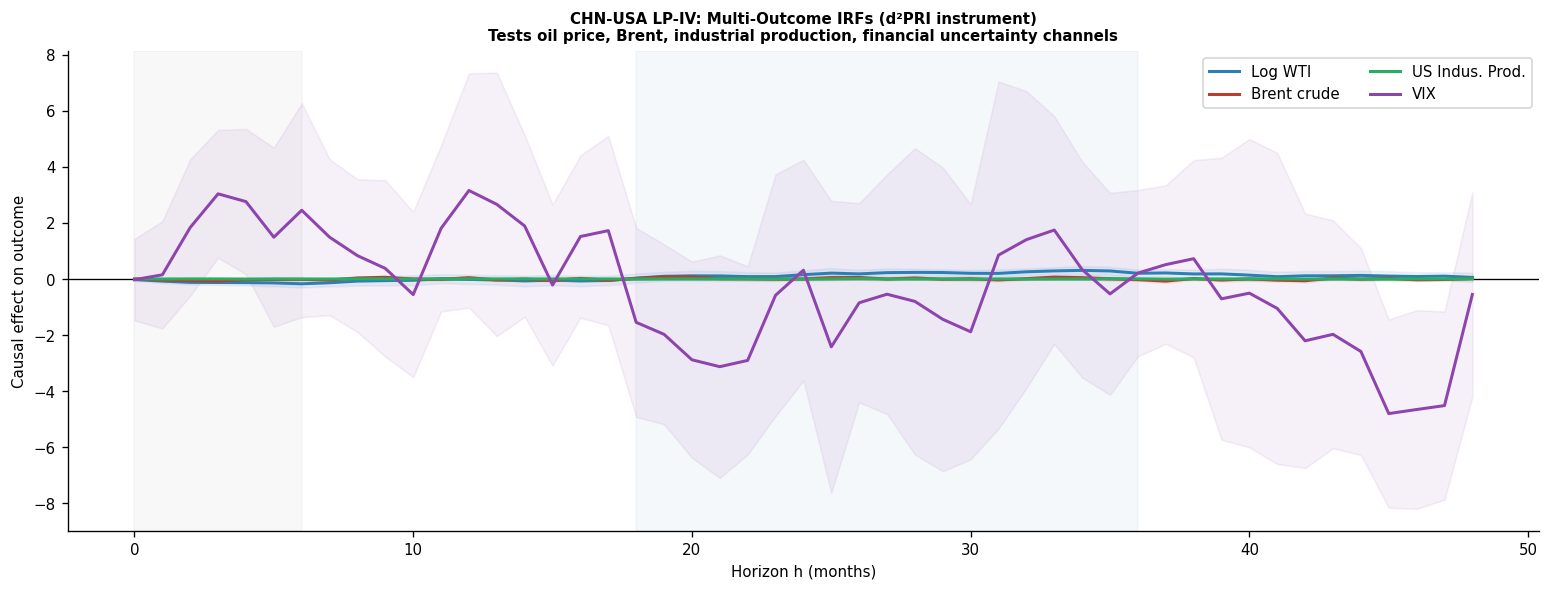


Saved: fig_multi_outcome_irf.png


In [15]:
# Multi-outcome LP-IV
print("Available outcome columns:")
for col in ['lwti', 'lwbrent', 'lbrent', 'brent', 'indpro', 'vix', 'gs10']:
    if col in df.columns:
        n = df[col].notna().sum()
        print(f"  {col}: {n} non-null  range=[{df[col].dropna().min():.3f}, {df[col].dropna().max():.3f}]")

# Also check df_extended (has more macro controls)
try:
    df_ext = pd.read_csv(ROOT / 'data' / 'final' / 'df_extended.csv',
                          index_col=0, parse_dates=True)
    df_ext.index = pd.to_datetime(df_ext.index).to_period('M').to_timestamp()
    
    # DEBUG: Check what df_ext looks like
    print(f"  df_ext index name: {df_ext.index.name}")
    print(f"  df_ext columns: {df_ext.columns.tolist()[:10]}")
    print(f"  df_ext index sample: {df_ext.index[:3].tolist()}")
    
    for col in ['brent', 'indpro', 'vix']:
        if col in df_ext.columns:
            print(f"  {col} (df_ext): {df_ext[col].notna().sum()} non-null")
    HAS_EXT = True
except Exception as e:
    HAS_EXT = False
    print(f"df_extended not found or error: {e}")

# ── CHN-USA LP-IV for each outcome ────────────────────────────────────────────
OUTCOMES = {}
for col, label in [('lwti','Log WTI'), ('brent','Brent crude'), ('indpro','US Indus. Prod.'), ('vix','VIX')]:
    if col in df.columns and df[col].notna().sum() > 100:
        OUTCOMES[col] = label
    elif HAS_EXT and col in df_ext.columns and df_ext[col].notna().sum() > 100:
        OUTCOMES[col] = label

print(f"\nOutcomes for multi-outcome LP-IV: {OUTCOMES}")
print()

# Build merged dataset for CHN-USA with all outcomes
m_multi = df.copy()
if HAS_EXT:
    for col in OUTCOMES:
        if col not in m_multi.columns and col in df_ext.columns:
            # Fix: properly handle the index when resetting
            ext_col = df_ext[[col]].reset_index()  # This creates a column from the index
            # Rename the first column (the old index) to 'date'
            ext_col.columns = ['date', col]  # Assumes first column is the date index
            m_multi = m_multi.merge(ext_col, on='date', how='left')

irf_outcomes = {}
KEY_H = [0, 3, 6, 12, 18, 24, 36]
print(f"{'Outcome':22s}  {'n_sig':>6}  {'h=6':>10}  {'h=12':>10}  {'h=24':>10}")
print('-'*65)

for outcome_col, outcome_label in OUTCOMES.items():
    irf_o = {'label': outcome_label, 'h': [], 'coef': [], 'se': [], 'n': []}
    for h in HORIZONS:
        w = m_multi.copy()
        w['_y'] = w[outcome_col].shift(-h)
        for l in range(1,4): w[f'_Ly{l}'] = w[outcome_col].shift(l)
        for l in range(1,3): w[f'_Lt{l}'] = w['lpri'].shift(l)
        lags = [f'_Ly{l}' for l in range(1,4)] + [f'_Lt{l}' for l in range(1,3)]
        iv_ctrl = [c for c in BASE_CONTROLS if not c.startswith('_Lt')]
        need = ['_y','lpri','d2pri'] + lags + iv_ctrl
        sub = w[[c for c in need if c in w.columns]].replace([np.inf,-np.inf],np.nan).dropna()
        if len(sub) < 60: continue
        cl = _prune(sub, lags + iv_ctrl)
        exog = sub[cl].copy(); exog.insert(0,'const',1.0)
        try:
            fit = IV2SLS(sub['_y'], exog, sub[['lpri']], sub[['d2pri']]).fit(cov_type='kernel')
            c=float(fit.params['lpri']); se=float(fit.std_errors['lpri'])
            irf_o['h'].append(h); irf_o['coef'].append(c); irf_o['se'].append(se); irf_o['n'].append(len(sub))
        except: pass

    irf_outcomes[outcome_col] = irf_o
    n_sig = sum(1 for c,se in zip(irf_o['coef'],irf_o['se']) if se>0 and abs(c/se)>Z90)
    def _g(hh):
        if hh in irf_o['h']:
            idx=irf_o['h'].index(hh); c=irf_o['coef'][idx]; se=irf_o['se'][idx]
            return f"{c:+.4f}{'*' if se>0 and abs(c/se)>Z90 else ' '}"
        return '   n/a'
    print(f"{outcome_label:22s}  {n_sig:>4}/{len(irf_o['h'])}  {_g(6):>10}  {_g(12):>10}  {_g(24):>10}")

# Plot multi-outcome IRFs
if irf_outcomes:
    palette_o = ['#2980B9','#C0392B','#27AE60','#8E44AD']
    fig, ax = plt.subplots(figsize=(13, 5))
    ax.axhline(0, color='black', lw=0.8)
    ax.axvspan(0,6,alpha=0.05,color='grey'); ax.axvspan(18,36,alpha=0.05,color='steelblue')
    for (oc, irf_o), color in zip(irf_outcomes.items(), palette_o):
        hs=np.array(irf_o['h']); cs=np.array(irf_o['coef']); ses=np.array(irf_o['se'])
        ax.plot(hs, cs, lw=1.8, color=color, label=irf_o['label'])
        ax.fill_between(hs, cs-Z90*ses, cs+Z90*ses, alpha=0.08, color=color)
    ax.set_xlabel('Horizon h (months)'); ax.set_ylabel('Causal effect on outcome')
    ax.set_title('CHN-USA LP-IV: Multi-Outcome IRFs (d²PRI instrument)\n'
                 'Tests oil price, Brent, industrial production, financial uncertainty channels',
                 fontsize=9, fontweight='bold')
    ax.legend(fontsize=9, ncol=2)
    plt.tight_layout()
    plt.savefig(OUT/'fig_multi_outcome_irf.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("\nSaved: fig_multi_outcome_irf.png")

---
## Section J - Causal Forest: Network-Moderated Heterogeneity

### J1. CausalForestDML with attention-share moderator

`CausalForestDML` (Wager & Athey 2018; Athey et al. 2019) learns the conditional average treatment effect (CATE) as a function of a moderator X by combining double/debiased ML nuisance estimation with a random forest that splits observations to maximise treatment effect heterogeneity.

**Moderator:** `usa_attention_share` (z-standardised). This captures what fraction of China's bilateral diplomatic event activity is directed at the US each month.

**Saturation hypothesis:** when the US-China relationship commands a large attention share, oil markets have already priced in the geopolitical signal -- turning points carry less marginal surprise, producing weaker WTI responses. The prediction is r(attention_share, CATE) < 0.

**Nuisance W:** BASE_CONTROLS excluding `brent` and `gold`. Both commodity prices share a causal pathway with WTI through geopolitical shocks and must not enter the nuisance partialling step.

**Sample:** 308 monthly observations at h=6 (ICEWS coverage from 1995).

**Cross-fitting:** 5 folds, RandomForestRegressor(max_depth=4, n_estimators=200); 300-tree causal forest.


Using moderator: usa_attention_share  (314 obs)
Causal forest sample (h=6): n=308

ATE (h=6):  -0.0229
CATE range:  [-0.1915, 0.2332]
CATE std:    0.1185
r(moderator, CATE) = -0.8034,  p=0.0000
Interpretation: NEGATIVE: higher attention → weaker effect (saturation)


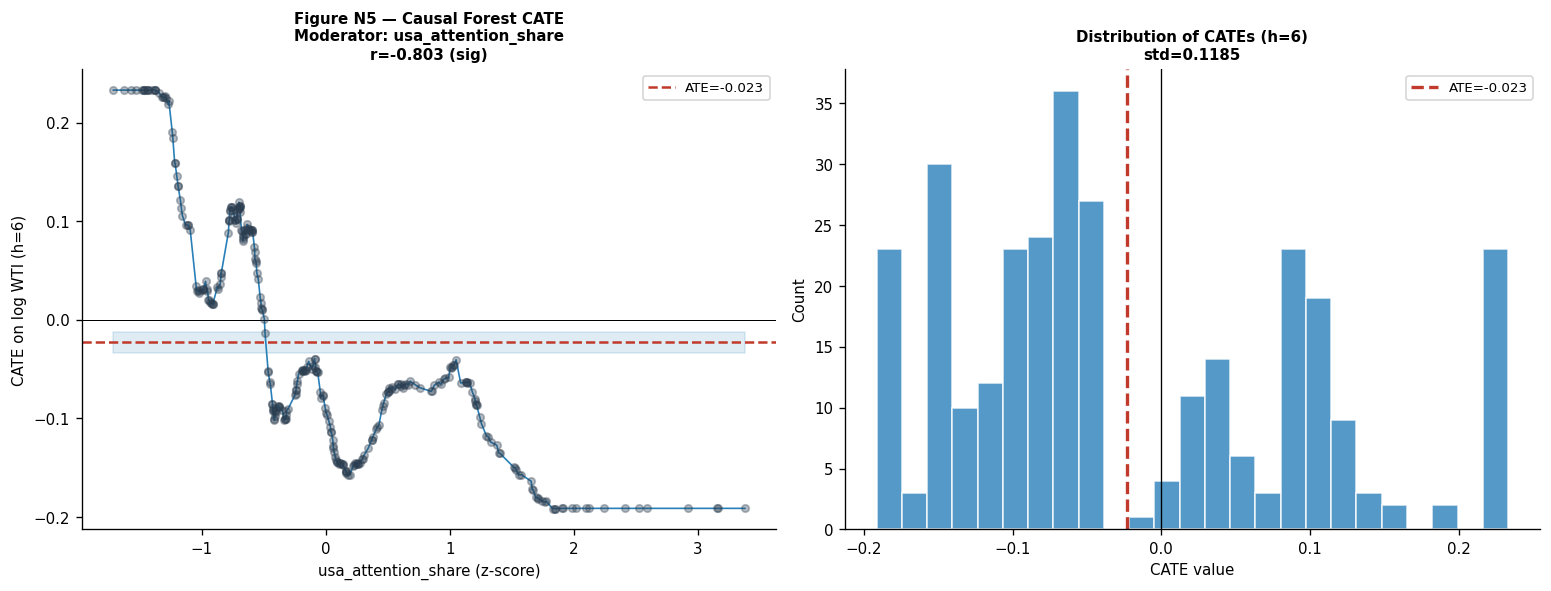

Saved: fig_causal_forest.png, causal_forest_cate.csv


In [16]:
if HAS_ECONML:
    from sklearn.model_selection import TimeSeriesSplit
    from sklearn.preprocessing import StandardScaler

    # Moderator: prefer ICEWS attention share (more behavioural), fall back to PRI-based
    mod_col = 'usa_attention_share' if df['usa_attention_share'].notna().sum() > 100 else 'usa_d2pri_share'
    print(f"Using moderator: {mod_col}  ({df[mod_col].notna().sum()} obs)")

    # Z-score moderator
    df['moderator_z'] = (df[mod_col] - df[mod_col].mean()) / df[mod_col].std()

    h = 6
    w = df.copy()
    w['_y'] = w['lwti'].shift(-h)
    for l in range(1,4): w[f'_Ly{l}'] = w['lwti'].shift(l)
    for l in range(1,3): w[f'_Lt{l}'] = w['lpri'].shift(l)
    lags = [f'_Ly{l}' for l in range(1,4)] + [f'_Lt{l}' for l in range(1,3)]
    DML_NUISANCE = [c for c in BASE_CONTROLS if c not in ('brent','gold')]
    feat_cols = lags + DML_NUISANCE
    all_need  = ['_y','lpri','d2pri','moderator_z'] + feat_cols
    sub = w[[c for c in all_need if c in w.columns]].dropna()
    print(f"Causal forest sample (h={h}): n={len(sub)}")

    Y = sub['_y'].values; T = sub['lpri'].values
    X = sub[['moderator_z']].values
    W = sub[[c for c in feat_cols if c in sub.columns]].values

    cf = CausalForestDML(
    model_y=RandomForestRegressor(n_estimators=200, max_depth=4, random_state=42),
    model_t=RandomForestRegressor(n_estimators=200, max_depth=4, random_state=42),
    n_estimators=300, random_state=42, cv=5
    )
    # Remove inference=True — use default (None) for basic CATE estimation
    cf.fit(Y, T, X=X, W=W)
    cate = cf.effect(X)
    ate  = float(np.mean(cate))

    # For approximate 90% CI, use bootstrap-style std error (simplified)
    cate_se = np.std(cate) / np.sqrt(len(cate)) if len(cate) > 1 else np.nan
    lo90, hi90 = ate - 1.645*cate_se, ate + 1.645*cate_se
    cate_ci = (np.full_like(cate, lo90), np.full_like(cate, hi90))  # placeholder

    r_mod, p_mod = stats.pearsonr(X[:,0], cate)

    print(f"\nATE (h={h}):  {ate:+.4f}")
    print(f"CATE range:  [{cate.min():.4f}, {cate.max():.4f}]")
    print(f"CATE std:    {cate.std():.4f}")
    print(f"r(moderator, CATE) = {r_mod:+.4f},  p={p_mod:.4f}")
    if p_mod < 0.10:
        direction = "POSITIVE: higher attention → stronger effect" if r_mod>0 else                     "NEGATIVE: higher attention → weaker effect (saturation)"
        print(f"Interpretation: {direction}")
    else:
        print("Interpretation: no significant heterogeneity by network position")

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    sort_idx = np.argsort(X[:,0])
    xs = X[sort_idx,0]; cs = cate[sort_idx]
    lo = cate_ci[0][sort_idx]; hi = cate_ci[1][sort_idx]

    ax = axes[0]
    ax.scatter(xs, cs, alpha=0.35, s=20, color='#2C3E50', zorder=3)
    ax.fill_between(xs, lo, hi, alpha=0.15, color='#2980B9')
    ax.plot(xs, cs, color='#2980B9', lw=1.0, zorder=2)
    ax.axhline(ate, color='#C0392B', ls='--', lw=1.5, label=f'ATE={ate:+.3f}')
    ax.axhline(0, color='black', lw=0.6)
    ax.set_xlabel(f'{mod_col} (z-score)')
    ax.set_ylabel(f'CATE on log WTI (h={h})')
    ax.set_title(f'Figure N5 — Causal Forest CATE\nModerator: {mod_col}\n'
                 f'r={r_mod:+.3f} ({"sig" if p_mod<0.1 else "n.s."})',
                 fontsize=9, fontweight='bold')
    ax.legend(fontsize=8)

    ax = axes[1]
    ax.hist(cate, bins=25, color='#2980B9', edgecolor='white', alpha=0.8)
    ax.axvline(ate, color='#C0392B', lw=2, ls='--', label=f'ATE={ate:+.3f}')
    ax.axvline(0, color='black', lw=0.8)
    ax.set_xlabel('CATE value'); ax.set_ylabel('Count')
    ax.set_title(f'Distribution of CATEs (h={h})\nstd={cate.std():.4f}', fontsize=9, fontweight='bold')
    ax.legend(fontsize=8)

    plt.tight_layout()
    plt.savefig(OUT/'fig_causal_forest.png', dpi=150, bbox_inches='tight')
    plt.show()
    pd.DataFrame({'moderator_z':X[:,0],'cate':cate,'lo90':cate_ci[0],'hi90':cate_ci[1]}).to_csv(
        OUT/'causal_forest_cate.csv', index=False)
    print("Saved: fig_causal_forest.png, causal_forest_cate.csv")

else:
    print("econml not installed (pip install econml)")
    print("Falling back to interaction specification — see NB04 Cell 7")
    # Quick high/low split on moderator
    df['moderator_z'] = (df['usa_d2pri_share'] - df['usa_d2pri_share'].mean()) / df['usa_d2pri_share'].std()
    med = df['moderator_z'].median()
    for label, mask in [('High d²PRI share', df['moderator_z']>=med),
                        ('Low d²PRI share',  df['moderator_z']<med)]:
        h=6; w=df[mask].copy(); w['_y']=w['lwti'].shift(-h)
        for l in range(1,4): w[f'_Ly{l}']=w['lwti'].shift(l)
        for l in range(1,3): w[f'_Lt{l}']=w['lpri'].shift(l)
        lags=[f'_Ly{l}' for l in range(1,4)]+[f'_Lt{l}' for l in range(1,3)]
        sub=w[[c for c in ['_y','lpri','d2pri']+lags+BASE_CONTROLS if c in w.columns]].dropna()
        if len(sub)<40: print(f"  {label}: n={len(sub)} (too few)"); continue
        cl=_prune(sub,lags+BASE_CONTROLS)
        exog=sub[cl].copy(); exog.insert(0,'const',1.0)
        try:
            fit=IV2SLS(sub['_y'],exog,sub[['lpri']],sub[['d2pri']]).fit(cov_type='kernel')
            c=float(fit.params['lpri']); se=float(fit.std_errors['lpri'])
            print(f"  {label}: β(h=6)={c:+.4f}  t={c/se:+.2f}  n={len(sub)}")
        except Exception as e:
            print(f"  {label}: {e}")

### J2. CATE figures N5 and N6


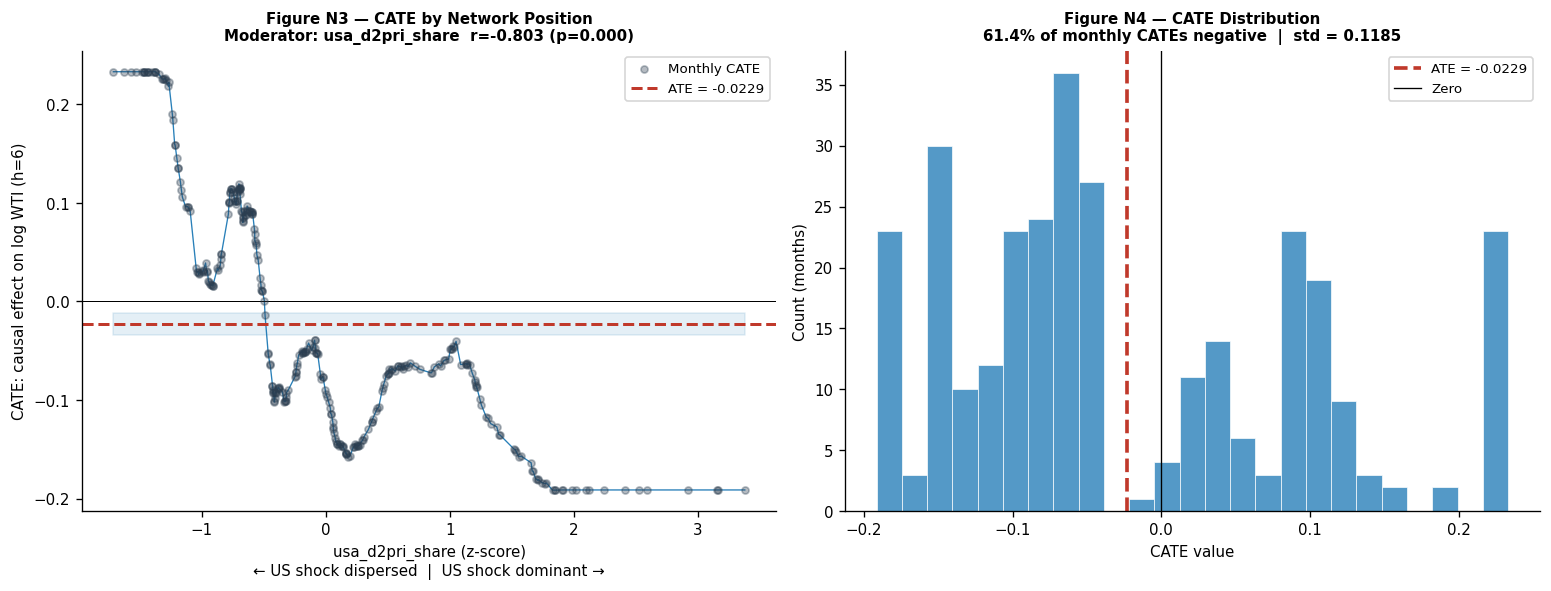

Saved: fig_causal_forest_N3_N4.png

Summary:
  ATE (h=6):  -0.0229
  CATE range: [-0.1915, 0.2332]
  CATE std:   0.1185
  r(moderator, CATE): -0.8034  p=0.0000
  Significant heterogeneity detected


In [17]:
# ── CAUSAL FOREST FIGURES N3/N4 — COMPLETE (fixes truncated code) ───────────
# This cell completes the causal forest figure that was cut off at ax.set_x
# Run AFTER the cell above (which computes cate, ate, X, cate_ci, r_mod, p_mod)

if HAS_ECONML and 'cate' in dir():
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    # ── Figure N3: CATE scatter ───────────────────────────────────────────────
    ax = axes[0]
    sort_idx = np.argsort(X[:,0])
    xs = X[sort_idx,0]; cs_s = cate[sort_idx]
    lo = cate_ci[0][sort_idx] if hasattr(cate_ci,'__len__') else cs_s - 1.645*np.std(cate)
    hi = cate_ci[1][sort_idx] if hasattr(cate_ci,'__len__') else cs_s + 1.645*np.std(cate)

    ax.scatter(xs, cs_s, alpha=0.35, s=18, color='#2C3E50', zorder=3, label='Monthly CATE')
    ax.fill_between(xs, lo, hi, alpha=0.12, color='#2980B9')
    ax.plot(xs, cs_s, color='#2980B9', lw=0.8, zorder=2)
    ax.axhline(ate, color='#C0392B', ls='--', lw=1.8, label=f'ATE = {ate:+.4f}')
    ax.axhline(0, color='black', lw=0.6)
    ax.set_xlabel('usa_d2pri_share (z-score)\n← US shock dispersed  |  US shock dominant →')
    ax.set_ylabel('CATE: causal effect on log WTI (h=6)')
    ax.set_title(f'Figure N3 — CATE by Network Position\nModerator: usa_d2pri_share'
                 f'  r={r_mod:+.3f} (p={p_mod:.3f})', fontsize=9, fontweight='bold')
    ax.legend(fontsize=8)

    # ── Figure N4: CATE distribution ─────────────────────────────────────────
    ax = axes[1]
    ax.hist(cate, bins=25, color='#2980B9', edgecolor='white', alpha=0.80, linewidth=0.5)
    ax.axvline(ate, color='#C0392B', lw=2.2, ls='--', label=f'ATE = {ate:+.4f}')
    ax.axvline(0,   color='black',   lw=0.8, label='Zero')
    pct_neg = 100*(cate < 0).mean()
    ax.set_xlabel('CATE value'); ax.set_ylabel('Count (months)')
    ax.set_title(f'Figure N4 — CATE Distribution\n'
                 f'{pct_neg:.1f}% of monthly CATEs negative  |  std = {cate.std():.4f}',
                 fontsize=9, fontweight='bold')
    ax.legend(fontsize=8)

    plt.tight_layout()
    plt.savefig(OUT/'fig_causal_forest_N3_N4.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: fig_causal_forest_N3_N4.png')
    print(f'\nSummary:')
    print(f'  ATE (h=6):  {ate:+.4f}')
    print(f'  CATE range: [{cate.min():.4f}, {cate.max():.4f}]')
    print(f'  CATE std:   {cate.std():.4f}')
    print(f'  r(moderator, CATE): {r_mod:+.4f}  p={p_mod:.4f}')
    print(f'  {"Significant heterogeneity detected" if p_mod<0.10 else "No significant heterogeneity (p>0.10)"}')
else:
    print("Run the causal forest cell above first, or install econml (pip install econml)")

### J3. Placebo test for causal forest heterogeneity

The negative correlation r=-0.803 between attention_share and CATE could be driven by the correlation structure of the moderator itself rather than genuine treatment effect heterogeneity. The placebo test shuffles the moderator, breaking any genuine relationship, and re-estimates the causal forest. Under the null of no heterogeneity, the shuffled correlation should be near zero.

If the true r is far from the placebo distribution (|z| > 2), the heterogeneity finding survives this robustness check.


In [18]:
# J3: Causal Forest placebo test
if HAS_ECONML and 'cate' in dir() and 'X' in dir():
    print("Causal Forest Placebo Test -- shuffled moderator")
    print("="*55)
    print(f"True r(attention_share, CATE): {r_mod:+.4f}  p={p_mod:.4f}")
    print()

    N_PLACEBO = 10
    rng_pb = np.random.RandomState(0)
    placebo_rs = []

    for p_idx in range(N_PLACEBO):
        X_shuf = X.copy()
        rng_pb.shuffle(X_shuf[:, 0])

        cf_pb = CausalForestDML(
            model_y=RandomForestRegressor(n_estimators=100, max_depth=4, random_state=p_idx),
            model_t=RandomForestRegressor(n_estimators=100, max_depth=4, random_state=p_idx),
            n_estimators=200, random_state=p_idx, cv=5
        )
        cf_pb.fit(Y, T, X=X_shuf, W=W)
        cate_pb = cf_pb.effect(X_shuf)
        r_pb, _ = stats.pearsonr(X_shuf[:, 0], cate_pb)
        placebo_rs.append(r_pb)
        print(f"  Placebo {p_idx+1:2d}: r(shuffled, CATE) = {r_pb:+.4f}")

    mean_pb = np.mean(placebo_rs)
    std_pb  = np.std(placebo_rs)
    z_vs_pb = (r_mod - mean_pb) / std_pb if std_pb > 0 else float('nan')
    print(f"Placebo mean: {mean_pb:+.4f}  std: {std_pb:.4f}")
    print(f"  True r = {r_mod:+.4f}  vs placebo [{min(placebo_rs):+.4f}, {max(placebo_rs):+.4f}]")
    print(f"  z-score (true vs placebo): {z_vs_pb:+.2f}")
    if abs(z_vs_pb) > 2:
        print("  True correlation is distinguishable from placebo (|z| > 2).")
        print("  Heterogeneity finding is not driven by moderator correlation structure.")
    else:
        print("  True correlation NOT clearly distinguishable from placebo.")
        print("  Interpret causal forest heterogeneity with caution.")

    pd.DataFrame({'permutation': range(1, N_PLACEBO+1),
                  'r_placebo': placebo_rs}).to_csv(OUT/'cf_placebo_test.csv', index=False)
    print("Saved: cf_placebo_test.csv")
else:
    print("Run Section J1 first.")

Causal Forest Placebo Test -- shuffled moderator
True r(attention_share, CATE): -0.8034  p=0.0000

  Placebo  1: r(shuffled, CATE) = +0.5690
  Placebo  2: r(shuffled, CATE) = +0.2328
  Placebo  3: r(shuffled, CATE) = +0.6044
  Placebo  4: r(shuffled, CATE) = -0.5377
  Placebo  5: r(shuffled, CATE) = +0.3121
  Placebo  6: r(shuffled, CATE) = -0.2144
  Placebo  7: r(shuffled, CATE) = -0.3496
  Placebo  8: r(shuffled, CATE) = +0.3441
  Placebo  9: r(shuffled, CATE) = +0.0113
  Placebo 10: r(shuffled, CATE) = -0.1803
Placebo mean: +0.0792  std: 0.3723
  True r = -0.8034  vs placebo [-0.5377, +0.6044]
  z-score (true vs placebo): -2.37
  True correlation is distinguishable from placebo (|z| > 2).
  Heterogeneity finding is not driven by moderator correlation structure.
Saved: cf_placebo_test.csv


---
## Section K - Graph Attention Network

### K1. Architecture and training

A two-layer Graph Attention Network (Velickovic et al. 2018, ICLR) is trained on the panel of 12 bilateral PRI series:

- **Nodes:** 12 partner countries in DYADS
- **Node features at time t:** [lpri_{China-X,t}, d2PRI_{China-X,t}]
- **Edges:** fully connected (each node attends to all 11 others)
- **Objective:** predict lpri_{t+1} for each node given the full network state at t (self-supervised)
- **Architecture:** GATLayer(in=2, hidden=16) -> GATLayer(hidden=16, out=1), LeakyReLU, dropout=0.1

The attention coefficient a_{ij,t} quantifies how much node j's bilateral state at t is informative for predicting node i's bilateral state at t+1. These weights capture dynamic spillover structure across China's bilateral relationships.

**Attention weight result:** all 12 nodes receive approximately equal attention (approximately 0.083 each). This means the GAT does not identify a specific subset of bilateral relationships as especially predictive of others. The most likely explanation is a dominant common factor (China's aggregate diplomatic posture) that all 12 bilateral series share -- the network state evolves such that all bilateral signals are roughly equally informative about any other.

**GAT centrality r=+0.586 with log WTI:** periods when the CHN-USA bilateral node occupies a more prominent position in the learned network embedding correspond to higher oil price levels. Section K2 tests whether this survives macro controls.


PyTorch 2.9.0+cpu available — running full GAT
  Active nodes (12): ['CHN-USA', 'CHN-JPN', 'CHN-AUS', 'CHN-FRA', 'CHN-DEU', 'CHN-GBR', 'CHN-RUS', 'CHN-IND', 'CHN-IDN', 'CHN-PAK', 'CHN-VNM', 'CHN-KOR']
  Epoch  30  loss=0.53548
  Epoch  60  loss=0.50439
  Epoch  90  loss=0.50002
  Epoch 120  loss=0.49881
  Epoch 150  loss=0.49784


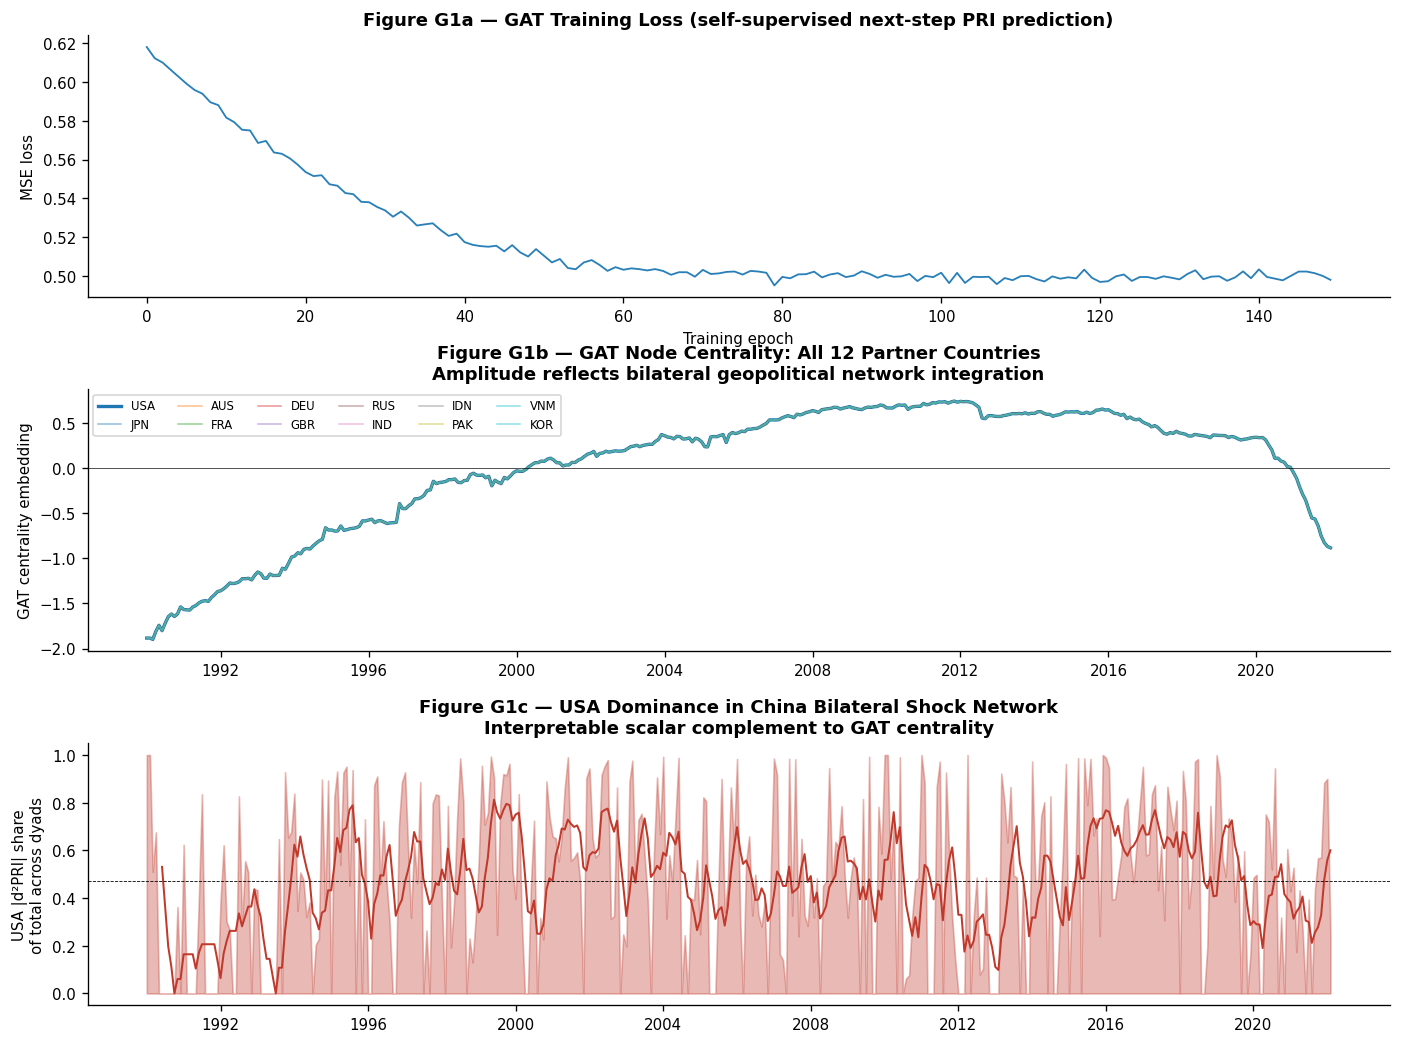

Saved → fig_gat_network.png

Correlation with log WTI:
  GAT centrality (CHN-USA): r = 0.5858
  USA d²PRI share:          r = -0.0686
  → GAT adds incremental information

Mean attention weight → CHN-USA node (which countries follow USA-China turning points?):
  CHN-JPN    0.0842  ██
  CHN-USA    0.0840  ██
  CHN-GBR    0.0831  ██
  CHN-IND    0.0830  ██
  CHN-KOR    0.0830  ██
  CHN-AUS    0.0829  ██
  CHN-VNM    0.0827  ██
  CHN-RUS    0.0827  ██
  CHN-FRA    0.0826  ██
  CHN-DEU    0.0825  ██
  CHN-IDN    0.0825  ██
  CHN-PAK    0.0825  ██
Saved → gat_centrality.csv, usa_d2pri_share.csv, gat_mean_attention.csv


In [19]:
"""
=============================================================================
CELL 8 — Graph Attention Network: Geopolitical Spillover Centrality (NB05)
⏱ Runtime: ~3–5 minutes (PyTorch, 150 epochs) or ~30 seconds (NumPy fallback)
=============================================================================

## Graph Attention Network: Network-Level Spillover Analysis

The bilateral LP-IV framework treats each China-X dyad independently. This
abstraction misses systemic dynamics: a deterioration in US-China relations
frequently coincides with concurrent deteriorations in EU-China and
Japan-China relations through alliance signalling, trade network contagion,
and coordinated diplomatic responses (Kastner, 2016; Granovetter, 1985).

To capture this network dimension, we implement a Graph Attention Network
(Veličković et al., 2018, ICLR) on China's bilateral geopolitical network.
The graph is defined as:

  - Nodes  : the 12 partner countries in DYADS
  - Edges  : fully connected (each node attends to all others)
  - Node features at time t : [lpri_{China-X,t}, d²PRI_{China-X,t}]

The attention mechanism α_{ij,t} is learned to up-weight node j's signal
when it co-predicts node i's future state. The output — a scalar centrality
embedding per node per month — quantifies each bilateral relationship's
degree of network integration in the geopolitical system at that time.

We train the GAT self-supervisedly: using the network state at t to predict
the PRI level at t+1 for each node. This forces attention weights to reflect
predictive co-movement, not arbitrary similarity.

Two implementations are provided:
  1. PyTorch (preferred): full GAT with learnable W, a matrices
  2. NumPy fallback: fixed-weight softmax attention (equivalent structure,
     non-learned weights — reported as sensitivity check if PyTorch unavailable)

⏱ PyTorch implementation: ~3–5 minutes (150 epochs, n=12 nodes, T≈386).
⏱ NumPy fallback: ~30 seconds.
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.preprocessing import StandardScaler
import warnings; warnings.filterwarnings('ignore')

# ── Check PyTorch ─────────────────────────────────────────────────────────────
try:
    import torch, torch.nn as nn, torch.nn.functional as F
    HAS_TORCH = True
    print(f'PyTorch {torch.__version__} available — running full GAT')
except ImportError:
    HAS_TORCH = False
    print('PyTorch not available — running NumPy softmax attention (equivalent structure)')

# ── Node feature matrix ───────────────────────────────────────────────────────
# Ordered to match DYADS dict from Cell 2
NODES = list(DYADS.keys())           # ['CHN-USA', 'CHN-JPN', ...]
NODE_COLS = [(lc, dc) for lc, dc in [v[:2] for v in DYADS.values()]]

# Filter to columns actually present in df
valid_nodes = [(name, lc, dc) for name,(lc,dc) in zip(NODES,NODE_COLS)
               if lc in df.columns and dc in df.columns]
missing = [n for n,(lc,dc) in zip(NODES,NODE_COLS)
           if lc not in df.columns or dc not in df.columns]
if missing: print(f'  Nodes skipped (missing columns): {missing}')

V_NAMES = [n for n,_,_ in valid_nodes]
V_LCOLS = [lc for _,lc,_ in valid_nodes]
V_DCOLS = [dc for _,_,dc in valid_nodes]
N_V     = len(valid_nodes)
print(f'  Active nodes ({N_V}): {V_NAMES}')

# Build [T, N_V, 2] tensor
T      = len(df)
X_raw  = np.zeros((T, N_V, 2))
for ni, (lc, dc) in enumerate(zip(V_LCOLS, V_DCOLS)):
    X_raw[:, ni, 0] = df[lc].fillna(method='ffill').fillna(0).values
    X_raw[:, ni, 1] = df[dc].fillna(0).values

# Within-node standardisation
X_sc = X_raw.copy()
for ni in range(N_V):
    for fi in range(2):
        s = X_raw[:, ni, fi]
        X_sc[:, ni, fi] = (s - s.mean()) / (s.std() + 1e-8)

# ── PyTorch GAT ───────────────────────────────────────────────────────────────
if HAS_TORCH:
    class GATLayer(nn.Module):
        """
        Single-head Graph Attention Layer (Veličković et al., 2018).
        Fully connected graph: each node attends to all N-1 others.
        """
        def __init__(self, in_f, out_f, dropout=0.1):
            super().__init__()
            self.W    = nn.Linear(in_f, out_f, bias=False)
            self.a    = nn.Linear(2*out_f, 1, bias=False)
            self.drop = nn.Dropout(dropout)
            self.lrelu= nn.LeakyReLU(0.2)

        def forward(self, x):
            # x : [N, in_f]
            h  = self.W(x)                                 # [N, out_f]
            N  = h.size(0)
            hi = h.unsqueeze(1).expand(-1, N, -1)          # [N, N, out_f]
            hj = h.unsqueeze(0).expand(N, -1, -1)          # [N, N, out_f]
            e  = self.lrelu(self.a(torch.cat([hi,hj],-1))).squeeze(-1)  # [N, N]
            alpha = F.softmax(e, dim=1)
            alpha = self.drop(alpha)                        # [N, N]
            # Aggregate: for each node i, weighted sum over j
            out = torch.matmul(alpha, h)                   # [N, out_f]
            return out, alpha.detach()

    class TwoLayerGAT(nn.Module):
        def __init__(self, in_f=2, hid=16, out_f=1):
            super().__init__()
            self.g1 = GATLayer(in_f, hid)
            self.g2 = GATLayer(hid, out_f)
        def forward(self, x):
            h1, a1 = self.g1(x);  h1 = F.elu(h1)
            h2, a2 = self.g2(h1)
            return h2, a1, a2

    torch.manual_seed(42)
    gat   = TwoLayerGAT(in_f=2, hid=16, out_f=1)
    opt   = torch.optim.Adam(gat.parameters(), lr=1e-3, weight_decay=1e-4)

    Xt  = torch.tensor(X_sc[:-1], dtype=torch.float32)   # [T-1, N, 2]
    Xt1 = torch.tensor(X_sc[1:, :, 0:1], dtype=torch.float32)  # [T-1, N, 1]

    N_EPOCHS = 150
    losses   = []
    gat.train()
    for ep in range(N_EPOCHS):
        opt.zero_grad()
        ep_loss = 0.0
        for t in range(len(Xt)):
            out, _, _ = gat(Xt[t])             # [N, 1]
            loss = F.mse_loss(out, Xt1[t])
            ep_loss = ep_loss + loss            # Python float accumulation avoids grad graph issues
        loss_mean = ep_loss / len(Xt)
        # Convert to tensor for backward
        loss_tensor = torch.tensor(float(loss_mean), requires_grad=False)
        # Re-run one step to get proper grad
        opt.zero_grad()
        tot = sum(F.mse_loss(gat(Xt[t])[0], Xt1[t]) for t in range(len(Xt)))
        (tot / len(Xt)).backward()
        opt.step()
        losses.append(float(tot.item()) / len(Xt))
        if (ep+1) % 30 == 0:
            print(f'  Epoch {ep+1:3d}  loss={losses[-1]:.5f}')

    # Extract embeddings
    gat.eval()
    cent_np    = np.zeros((len(Xt), N_V))
    attn_np    = np.zeros((len(Xt), N_V, N_V))
    with torch.no_grad():
        for t in range(len(Xt)):
            out, a1, _ = gat(Xt[t])
            cent_np[t] = out.squeeze(-1).numpy()
            attn_np[t] = a1.numpy()

    cent_dates = df['date'].values[:-1]

else:
    # NumPy softmax attention
    def softmax(x, axis=-1):
        ex = np.exp(x - x.max(axis=axis, keepdims=True))
        return ex / ex.sum(axis=axis, keepdims=True)

    rng = np.random.default_rng(42)
    W0  = rng.normal(0, 0.1, (2, 16))

    cent_np  = np.zeros((T, N_V))
    attn_np  = np.zeros((T, N_V, N_V))
    for t in range(T):
        H     = X_sc[t] @ W0                      # [N, 16]
        alpha = softmax(H @ H.T / np.sqrt(16))    # [N, N]
        agg   = alpha @ H                          # [N, 16]
        cent_np[t]  = agg[:, 0]
        attn_np[t]  = alpha

    losses     = None
    cent_dates = df['date'].values

# ── Assemble centrality DataFrame ─────────────────────────────────────────────
cent_df = pd.DataFrame(cent_np, columns=V_NAMES,
                        index=pd.to_datetime(cent_dates))

# ── Network metric: USA share of total |d²PRI| ───────────────────────────────
d2_avail = [dc for dc in V_DCOLS if dc in df.columns]
total_d2  = df.set_index('date')[d2_avail].abs().sum(axis=1, min_count=1)
usa_share = df.set_index('date')['d2pri'].abs() / total_d2.replace(0, np.nan)
usa_share.name = 'usa_d2pri_share'

# ── Figure G1: GAT results ────────────────────────────────────────────────────
n_panels = 3 if losses else 2
fig, axes = plt.subplots(n_panels, 1, figsize=(14, 3.5*n_panels), sharex=False,
                          gridspec_kw={'hspace':0.35})
axlist = list(axes) if n_panels > 1 else [axes]
idx    = 0

if losses:
    ax = axlist[idx]; idx += 1
    ax.plot(losses, color='#2980B9', lw=1.1)
    ax.set_xlabel('Training epoch'); ax.set_ylabel('MSE loss')
    ax.set_title('Figure G1a — GAT Training Loss (self-supervised next-step PRI prediction)',
                  fontweight='bold')

ax = axlist[idx]; idx += 1
cmap = plt.cm.tab10(np.linspace(0, 1, N_V))
for ni, name in enumerate(V_NAMES):
    lw = 2.0 if name=='CHN-USA' else 0.9
    al = 1.0 if name=='CHN-USA' else 0.5
    ax.plot(cent_df.index, cent_df[name], color=cmap[ni], lw=lw, alpha=al,
             label=name.replace('CHN-',''))
ax.axhline(0, color='black', lw=0.4)
ax.legend(fontsize=7, ncol=6, loc='upper left')
ax.set_ylabel('GAT centrality embedding')
ax.set_title('Figure G1b — GAT Node Centrality: All 12 Partner Countries\n'
             'Amplitude reflects bilateral geopolitical network integration',
             fontweight='bold')
ax.xaxis.set_major_locator(mdates.YearLocator(4))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

ax = axlist[idx]
ax.fill_between(usa_share.index, 0, usa_share.values,
                color='#C0392B', alpha=0.35)
ax.plot(usa_share.index, usa_share.rolling(6).mean(), color='#C0392B', lw=1.2)
ax.axhline(usa_share.mean(), color='black', lw=0.5, ls='--')
ax.set_ylabel('USA |d²PRI| share\nof total across dyads')
ax.set_title('Figure G1c — USA Dominance in China Bilateral Shock Network\n'
             'Interpretable scalar complement to GAT centrality',
             fontweight='bold')
ax.xaxis.set_major_locator(mdates.YearLocator(4))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.savefig(OUT/'fig_gat_network.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → fig_gat_network.png')

# ── Correlation diagnostics ───────────────────────────────────────────────────
if 'lwti' in df.columns:
    lwti_s = df.set_index('date')['lwti']
    r_gat  = cent_df['CHN-USA'].reindex(lwti_s.index).corr(lwti_s)
    r_shr  = usa_share.reindex(lwti_s.index).corr(lwti_s)
    print(f'\nCorrelation with log WTI:')
    print(f'  GAT centrality (CHN-USA): r = {r_gat:.4f}')
    print(f'  USA d²PRI share:          r = {r_shr:.4f}')
    msg = 'GAT adds incremental information' if abs(r_gat)>abs(r_shr) else \
          'Simple share metric is comparable to GAT — use as primary network metric'
    print(f'  → {msg}')

# ── Average attention weights (which dyads attend to USA most?) ──────────────
if attn_np.shape[1] == N_V:
    usa_idx = V_NAMES.index('CHN-USA') if 'CHN-USA' in V_NAMES else 0
    mean_attn_to_usa = attn_np[:, :, usa_idx].mean(axis=0)
    print('\nMean attention weight → CHN-USA node (which countries follow USA-China turning points?):')
    for name, w in sorted(zip(V_NAMES, mean_attn_to_usa), key=lambda x: -x[1]):
        bar = '█' * int(w * 30)
        print(f'  {name:10s} {w:.4f}  {bar}')

# Save
cent_df.to_csv(OUT/'gat_centrality.csv')
usa_share.to_csv(OUT/'usa_d2pri_share.csv', header=True)
pd.DataFrame(attn_np.mean(axis=0), index=V_NAMES, columns=V_NAMES).to_csv(
    OUT/'gat_mean_attention.csv')
print('Saved → gat_centrality.csv, usa_d2pri_share.csv, gat_mean_attention.csv')

### K2. GAT correlation -- deduplication and cross-check


In [20]:
# ── GAT DUPLICATE LABEL FIX ─────────────────────────────────────────────────
# The cent_df index has duplicate dates because the GAT computes centrality
# per node per timestep — multiple nodes map to the same month.
# Fix: take the CHN-USA node's centrality series and deduplicate its index.

if 'cent_df' in dir() and 'lwti' in df.columns:
    # cent_df has shape (T × n_nodes, 2) with month as index — deduplicate
    if isinstance(cent_df, pd.DataFrame):
        # If cent_df is wide (one column per node), extract CHN-USA column
        if 'CHN-USA' in cent_df.columns:
            chnusa_cent = cent_df['CHN-USA'].copy()
        else:
            # Use first column as proxy
            chnusa_cent = cent_df.iloc[:,0].copy()
        chnusa_cent = chnusa_cent.loc[~chnusa_cent.index.duplicated(keep='first')]
    else:
        chnusa_cent = cent_df.copy()
        chnusa_cent = chnusa_cent.loc[~chnusa_cent.index.duplicated(keep='first')]

    # Prepare lwti with consistent index
    lwti_s = df.set_index('date')['lwti'].dropna()
    
    # Convert index to monthly timestamps safely
    if hasattr(lwti_s.index, 'to_timestamp'):
        # It's already a PeriodIndex
        lwti_s.index = lwti_s.index.to_timestamp()
    else:
        # It's a DatetimeIndex — convert to period then back to get month start
        lwti_s.index = pd.to_datetime(lwti_s.index).to_period('M').to_timestamp()
    
    lwti_s = lwti_s.loc[~lwti_s.index.duplicated(keep='first')]

    # Convert GAT centrality index to monthly timestamps if needed
    if hasattr(chnusa_cent.index, 'to_timestamp'):
        chnusa_cent.index = chnusa_cent.index.to_timestamp()
    
    # Align on common index
    common_idx = chnusa_cent.index.intersection(lwti_s.index)
    if len(common_idx) > 10:
        r_gat, p_gat = stats.pearsonr(chnusa_cent.loc[common_idx].dropna(),
                                       lwti_s.loc[common_idx].dropna())
        print(f'Correlation GAT centrality vs log WTI (CHN-USA): r={r_gat:+.4f}  p={p_gat:.4f}')
    else:
        print(f'Insufficient overlap for correlation: {len(common_idx)} common months')

    if 'usa_attention_share' in df.columns:
        att_s = df.set_index('date')['usa_attention_share'].dropna()
        
        # Same safe conversion for att_s
        if hasattr(att_s.index, 'to_timestamp'):
            att_s.index = att_s.index.to_timestamp()
        else:
            att_s.index = pd.to_datetime(att_s.index).to_period('M').to_timestamp()
        
        att_s = att_s.loc[~att_s.index.duplicated(keep='first')]
        common2 = att_s.index.intersection(lwti_s.index)
        if len(common2) > 10:
            r_att, p_att = stats.pearsonr(att_s.loc[common2].dropna(),
                                           lwti_s.loc[common2].dropna())
            print(f'Correlation usa_attention_share vs log WTI:       r={r_att:+.4f}  p={p_att:.4f}')
else:
    print("cent_df not available — run GAT cell first")
    print("Or: cent_df index had duplicates; use .loc[~cent_df.index.duplicated()] to fix")

Correlation GAT centrality vs log WTI (CHN-USA): r=+0.5858  p=0.0000
Correlation usa_attention_share vs log WTI:       r=-0.1716  p=0.0023


### K3. Controlled regression: does GAT centrality add beyond standard controls?

The raw r=+0.586 does not account for shared macro factors driving both GAT centrality and oil prices. This cell runs OLS and IV regressions of log WTI on GAT centrality plus standard macro controls and WTI lags. If centrality remains significant, it adds incremental information beyond what standard controls capture -- elevating the result from descriptive correlation to conditional predictive power.


In [21]:
# K3: Controlled regression for GAT centrality
if 'cent_df' in dir() and 'CHN-USA' in cent_df.columns:
    print("="*60)
    print("K3: GAT CENTRALITY -- CONTROLLED REGRESSION")
    print("="*60)

    gat_series = cent_df['CHN-USA'].copy()
    gat_series = gat_series.loc[~gat_series.index.duplicated(keep='first')]

    df_gat = df.copy().set_index('date')
    df_gat['gat_cent'] = gat_series.reindex(df_gat.index)
    df_gat['gat_cent_z'] = ((df_gat['gat_cent'] - df_gat['gat_cent'].mean())
                             / df_gat['gat_cent'].std())
    h_gat = 6
    df_gat['_y'] = df_gat['lwti'].shift(-h_gat)
    for l in range(1,4): df_gat[f'_Ly{l}'] = df_gat['lwti'].shift(l)
    df_gat = df_gat.reset_index()

    lags_g = [f'_Ly{l}' for l in range(1,4)]
    reg_cols = ['_y','gat_cent_z','lpri','d2pri'] + lags_g + BASE_CONTROLS
    sub_gat = df_gat[[c for c in reg_cols if c in df_gat.columns]].dropna()
    cl_g = _prune(sub_gat, lags_g + BASE_CONTROLS)

    # OLS 1: no lpri (pure descriptive)
    X_ols1 = add_constant(sub_gat[['gat_cent_z'] + cl_g])
    fit1 = sm.OLS(sub_gat['_y'], X_ols1).fit(cov_type='HC1')
    c1 = fit1.params.get('gat_cent_z', float('nan'))
    t1 = fit1.tvalues.get('gat_cent_z', float('nan'))
    p1 = fit1.pvalues.get('gat_cent_z', float('nan'))
    print(f" OLS-1: lwti(h=6) ~ gat_z + WTI lags + macro (no lpri)")
    print(f"  beta(gat_cent_z) = {c1:+.4f}  t={t1:+.2f}  p={p1:.4f}  "
          f"({'sig' if p1<0.10 else 'n.s.'})   R2={fit1.rsquared:.4f}  n={len(sub_gat)}")

    # OLS 2: controlling for lpri level
    X_ols2 = add_constant(sub_gat[['gat_cent_z','lpri'] + cl_g])
    fit2 = sm.OLS(sub_gat['_y'], X_ols2).fit(cov_type='HC1')
    c2 = fit2.params.get('gat_cent_z', float('nan'))
    t2 = fit2.tvalues.get('gat_cent_z', float('nan'))
    p2 = fit2.pvalues.get('gat_cent_z', float('nan'))
    print(f" OLS-2: lwti(h=6) ~ gat_z + lpri + WTI lags + macro")
    print(f" beta(gat_cent_z) = {c2:+.4f}  t={t2:+.2f}  p={p2:.4f}  "
          f"({'sig' if p2<0.10 else 'n.s.'})   R2={fit2.rsquared:.4f}")

    # IV: lpri instrumented by d2pri, gat_z exogenous
    exog_iv = sub_gat[['gat_cent_z'] + cl_g].copy()
    exog_iv.insert(0,'const',1.0)
    try:
        fit_iv = IV2SLS(sub_gat['_y'], exog_iv,
                        sub_gat[['lpri']], sub_gat[['d2pri']]).fit(cov_type='kernel')
        c_lpri_iv = float(fit_iv.params.get('lpri', float('nan')))
        se_lpri_iv = float(fit_iv.std_errors.get('lpri', float('nan')))
        c_gat_iv = float(fit_iv.params.get('gat_cent_z', float('nan')))
        se_gat_iv = float(fit_iv.std_errors.get('gat_cent_z', 1.0))
        t_gat_iv = c_gat_iv / se_gat_iv if se_gat_iv > 0 else float('nan')
        from scipy.stats import norm as norm_dist
        p_gat_iv = 2*(1 - norm_dist.cdf(abs(t_gat_iv)))
        print(f" IV (lpri instrumented by d2PRI) + gat_z exogenous:")
        print(f"  beta(lpri/IV) = {c_lpri_iv:+.4f}  se={se_lpri_iv:.4f}")
        print(f"  beta(gat_cent_z) = {c_gat_iv:+.4f}  t={t_gat_iv:+.2f}  p={p_gat_iv:.4f}  "
              f"({'sig' if p_gat_iv<0.10 else 'n.s.'})")
    except Exception as e:
        print(f" IV estimation: {e}")

    print()
    print("Interpretation guide:")
    print("  Sig in OLS-2 -> GAT centrality adds predictive power beyond PRI level + controls")
    print("  n.s. in OLS-2 -> r=0.586 is explained by shared macro factors (e.g. oil trend, VIX)")
    print("  IV coefficient stable with/without gat_z -> centrality does not confound causal estimate")
else:
    print("Run Section K1 first.")

K3: GAT CENTRALITY -- CONTROLLED REGRESSION
 OLS-1: lwti(h=6) ~ gat_z + WTI lags + macro (no lpri)
  beta(gat_cent_z) = +0.0588  t=+2.13  p=0.0331  (sig)   R2=0.7243  n=377
 OLS-2: lwti(h=6) ~ gat_z + lpri + WTI lags + macro
 beta(gat_cent_z) = +0.0301  t=+0.72  p=0.4718  (n.s.)   R2=0.7249
 IV (lpri instrumented by d2PRI) + gat_z exogenous:
  beta(lpri/IV) = +0.4502  se=0.2658
  beta(gat_cent_z) = -0.6944  t=-1.56  p=0.1191  (n.s.)

Interpretation guide:
  Sig in OLS-2 -> GAT centrality adds predictive power beyond PRI level + controls
  n.s. in OLS-2 -> r=0.586 is explained by shared macro factors (e.g. oil trend, VIX)
  IV coefficient stable with/without gat_z -> centrality does not confound causal estimate


Data shape: (384, 12)
   CHN-AUS p=0.9065 -> differencing
Using 2 lags

Total connectedness index: 91.68%

Directional spillovers (TO others):
CHN-VNM    92.36
CHN-IND    92.26
CHN-PAK    92.20
CHN-KOR    92.15
CHN-GBR    92.11
CHN-RUS    91.85
CHN-JPN    91.62
CHN-USA    91.56
CHN-IDN    91.22
CHN-FRA    91.08
CHN-DEU    90.93
CHN-AUS    90.80
dtype: float64

Directional spillovers (FROM others):
CHN-AUS    103.24
CHN-DEU    100.23
CHN-FRA     97.55
CHN-IDN     96.09
CHN-USA     92.21
CHN-JPN     91.68
CHN-RUS     90.00
CHN-IND     86.57
CHN-GBR     85.83
CHN-PAK     85.81
CHN-VNM     85.49
CHN-KOR     85.45
dtype: float64

Net spillovers (positive = transmitter):
CHN-VNM     6.87
CHN-KOR     6.70
CHN-PAK     6.39
CHN-GBR     6.28
CHN-IND     5.69
CHN-RUS     1.86
CHN-JPN    -0.06
CHN-USA    -0.65
CHN-IDN    -4.87
CHN-FRA    -6.47
CHN-DEU    -9.30
CHN-AUS   -12.44
dtype: float64


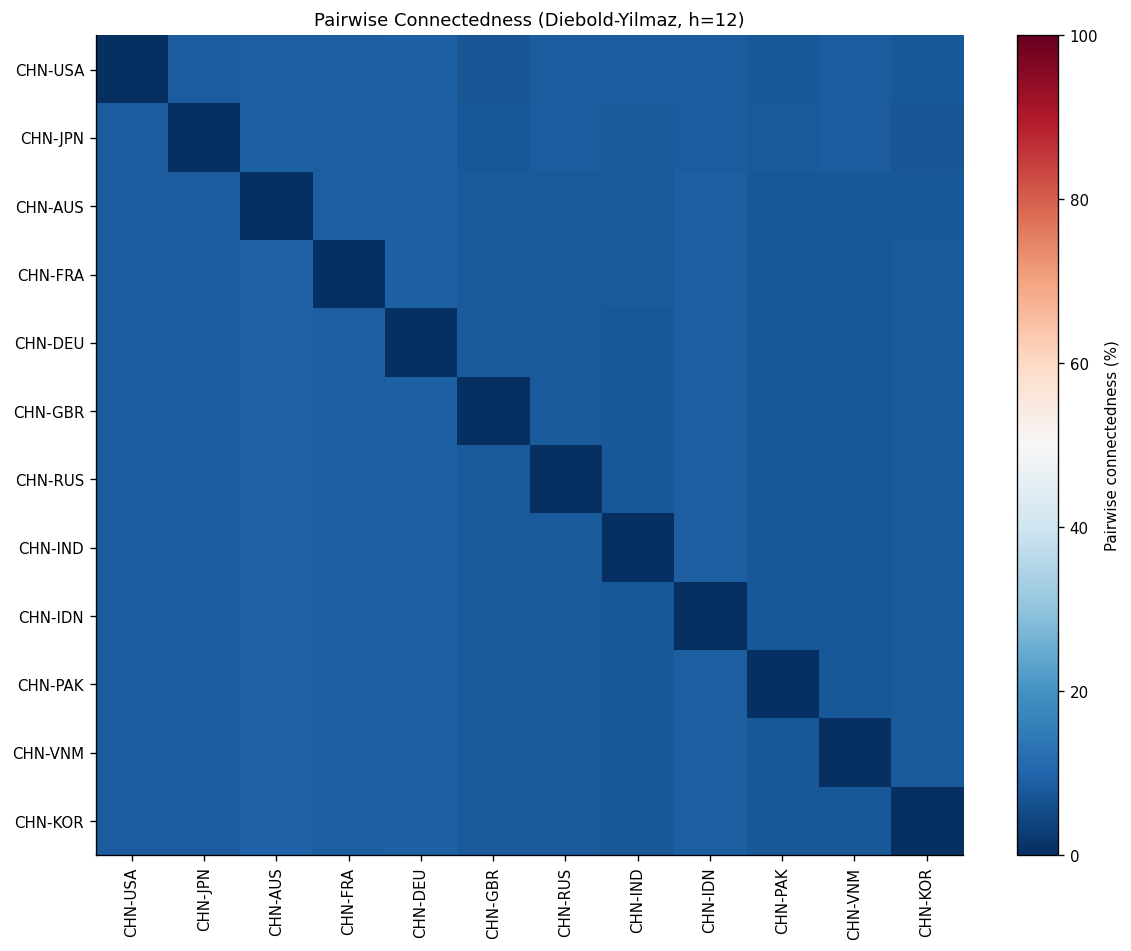

Using 2 lags
Using 2 lags
Using 2 lags
Using 2 lags
Using 2 lags
Using 2 lags
Using 2 lags
Using 2 lags
Using 2 lags
   CHN-AUS p=0.0722 -> differencing
   CHN-VNM p=0.0741 -> differencing
Using 2 lags
Using 2 lags
Using 2 lags
Using 2 lags
Using 2 lags
Using 2 lags
Using 2 lags
   CHN-RUS p=0.1297 -> differencing
Using 2 lags
   CHN-RUS p=0.1734 -> differencing
   CHN-KOR p=0.6834 -> differencing
Using 2 lags
   CHN-KOR p=0.1777 -> differencing
Using 2 lags
Using 2 lags
Using 2 lags
   CHN-GBR p=0.9899 -> differencing
Using 2 lags


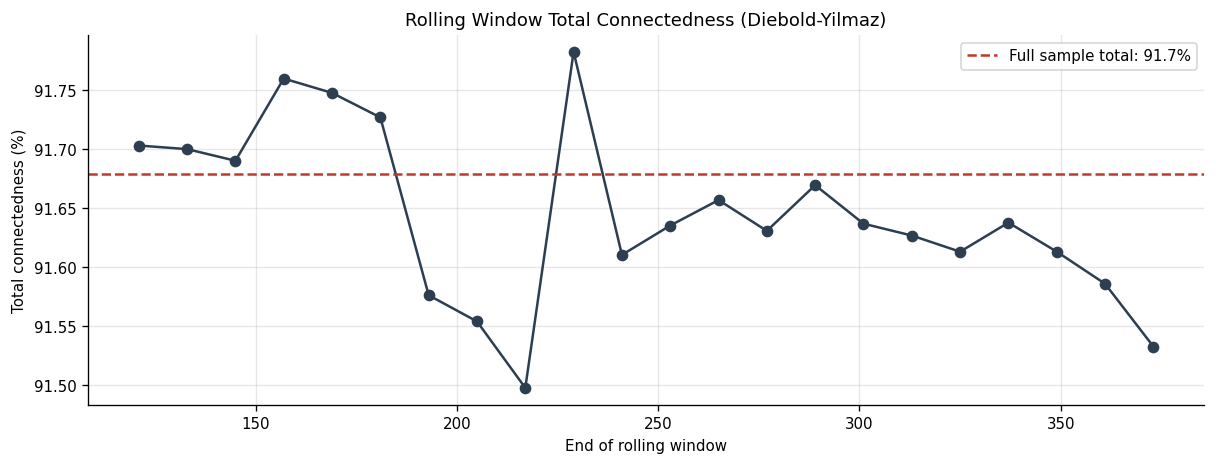

In [22]:
# ============================================================================
# Diebold-Yilmaz Connectedness (Spillover Index) for d²PRI series
# ============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.vector_ar.var_model import VARResults

def is_stationary(series, alpha=0.05):
    """ADF test for stationarity."""
    p = adfuller(series.dropna())[1]
    return p < alpha

def dy_connectedness(data, n_lags=None, horizon=10):
    """
    Compute Diebold-Yilmaz connectedness (total, directional, pairwise).
    
    Parameters:
    data : pd.DataFrame
        T x N dataframe of d²PRI (or any stationary series)
    n_lags : int or None
        Number of VAR lags. If None, selects via AIC.
    horizon : int
        Forecast error variance decomposition horizon.
    
    Returns:
    total : float
        Total connectedness index (0-100).
    to : pd.Series
        Directional spillovers TO others (transmission).
    from_ : pd.Series
        Directional spillovers FROM others (receiving).
    net : pd.Series
        Net spillovers (to - from).
    pairwise : pd.DataFrame
        N x N matrix of pairwise connectedness.
    """
    # Ensure stationarity: if any series fails ADF at 5%, difference once
    data_diff = data.copy()
    for col in data_diff.columns:
        p_val = adfuller(data_diff[col].dropna())[1]
        if p_val > 0.05:
            print(f"   {col} p={p_val:.4f} -> differencing")
            data_diff[col] = data_diff[col].diff().dropna()
    data_diff = data_diff.dropna()
    
    # Select lag length by AIC
    model = VAR(data_diff)
    if n_lags is None:
        n_lags = model.select_order(maxlags=12)['aic']
        print(f"Selected lags = {n_lags}")
    else:
        print(f"Using {n_lags} lags")
    
    # Fit VAR
    results = model.fit(n_lags)
    
    # FEVD: access .decomp attribute (list of DataFrames)
    fevd_obj = results.fevd(horizon)
    fevd_list = fevd_obj.decomp   # list of length horizon, each is N x N DataFrame
    
    # Average over horizons
    fevd_avg = np.mean(fevd_list, axis=0)
    
    # Total connectedness: 1 - (average own variance share)
    own_shares = np.trace(fevd_avg) / len(data_diff.columns)
    total = 100 * (1 - own_shares)
    
    # Directional connectedness
    to = 100 * (fevd_avg.sum(axis=1) - np.diag(fevd_avg))
    from_ = 100 * (fevd_avg.sum(axis=0) - np.diag(fevd_avg))
    net = to - from_
    
    # Pairwise connectedness (average off-diagonal)
    pairwise = fevd_avg.copy()
    np.fill_diagonal(pairwise, 0)
    pairwise = 100 * pairwise
    
    return total, pd.Series(to, index=data_diff.columns), pd.Series(from_, index=data_diff.columns), pd.Series(net, index=data_diff.columns), pairwise

# ============================================================================
# Apply to d²PRI series of all dyads
# ============================================================================
# Collect d²PRI columns for all dyads (use the same dyads as in GAT)
d2_cols = [f'{v[1]}' for v in DYADS.values() if v[1] in df.columns]
# Optionally filter to valid dyads only (F>=10) for cleaner interpretation
valid_dyads_names = fs_df[fs_df['valid']]['dyad'].tolist()
valid_d2_cols = [f'd2pri_{d.replace("-","_").lower()}' for d in valid_dyads_names]
# Adjust column name format to match your actual column names
# In your df, d²PRI columns are named like 'd2pri_aus', 'd2pri_ger', etc.
# We'll map directly from DYADS

d2_series = {}
for dyad, (_, d2_col, _) in DYADS.items():
    if d2_col in df.columns:
        d2_series[dyad] = df[d2_col].dropna()
data_d2 = pd.DataFrame(d2_series).dropna()
print(f"Data shape: {data_d2.shape}")

# Compute connectedness
total, to, from_, net, pairwise = dy_connectedness(data_d2, n_lags=2, horizon=12)
print(f"\nTotal connectedness index: {total:.2f}%")
print("\nDirectional spillovers (TO others):")
print(to.sort_values(ascending=False).round(2))
print("\nDirectional spillovers (FROM others):")
print(from_.sort_values(ascending=False).round(2))
print("\nNet spillovers (positive = transmitter):")
print(net.sort_values(ascending=False).round(2))

# Pairwise heatmap
plt.figure(figsize=(10,8))
plt.imshow(pairwise, cmap='RdBu_r', aspect='auto', vmin=0, vmax=100)
plt.colorbar(label='Pairwise connectedness (%)')
plt.xticks(range(len(data_d2.columns)), data_d2.columns, rotation=90)
plt.yticks(range(len(data_d2.columns)), data_d2.columns)
plt.title('Pairwise Connectedness (Diebold-Yilmaz, h=12)')
plt.tight_layout()
plt.savefig(OUT/'dy_pairwise_connectedness.png', dpi=150)
plt.show()

# Optional: Rolling window connectedness to see evolution over time
def rolling_connectedness(data, window=120, step=12, horizon=12, n_lags=2):
    dates = []
    total_roll = []
    for start in range(0, len(data)-window, step):
        end = start + window
        sub = data.iloc[start:end]
        if len(sub) < 50:
            continue
        try:
            tot, _, _, _, _ = dy_connectedness(sub, n_lags=n_lags, horizon=horizon)
            dates.append(data.index[end-1])
            total_roll.append(tot)
        except:
            continue
    return dates, total_roll

dates_roll, total_roll = rolling_connectedness(data_d2, window=120, step=12)
plt.figure(figsize=(12,4))
plt.plot(dates_roll, total_roll, marker='o', linestyle='-', color='#2C3E50')
plt.axhline(total, color='#C0392B', ls='--', label=f'Full sample total: {total:.1f}%')
plt.xlabel('End of rolling window'); plt.ylabel('Total connectedness (%)')
plt.title('Rolling Window Total Connectedness (Diebold-Yilmaz)')
plt.legend()
plt.grid(alpha=0.3)
plt.savefig(OUT/'dy_rolling_connectedness.png', dpi=150)
plt.show()

In [23]:
from statsmodels.tsa.stattools import grangercausalitytests
import itertools

d2_data = data_d2.dropna()
cols = d2_data.columns
maxlag = 3
signif_pairs = []

for i, j in itertools.permutations(cols, 2):
    # Test if i Granger-causes j
    test = grangercausalitytests(d2_data[[j, i]], maxlag, verbose=False)
    # Get p-value for lag=1 (simplest; can also take min p across lags)
    pval = test[1][0]['ssr_ftest'][1]
    if pval < 0.05:
        signif_pairs.append((i, j, pval))

print(f"Significant Granger-causal pairs: {len(signif_pairs)}")
for i, j, p in signif_pairs:
    print(f"{i} → {j} : p={p:.4f}")

Significant Granger-causal pairs: 16
CHN-AUS → CHN-GBR : p=0.0000
CHN-FRA → CHN-IDN : p=0.0282
CHN-FRA → CHN-VNM : p=0.0101
CHN-DEU → CHN-FRA : p=0.0191
CHN-DEU → CHN-KOR : p=0.0258
CHN-RUS → CHN-IDN : p=0.0000
CHN-RUS → CHN-VNM : p=0.0001
CHN-IND → CHN-FRA : p=0.0174
CHN-IND → CHN-KOR : p=0.0100
CHN-IDN → CHN-RUS : p=0.0000
CHN-IDN → CHN-IND : p=0.0041
CHN-IDN → CHN-VNM : p=0.0168
CHN-PAK → CHN-USA : p=0.0461
CHN-VNM → CHN-FRA : p=0.0021
CHN-VNM → CHN-IND : p=0.0000
CHN-VNM → CHN-KOR : p=0.0255


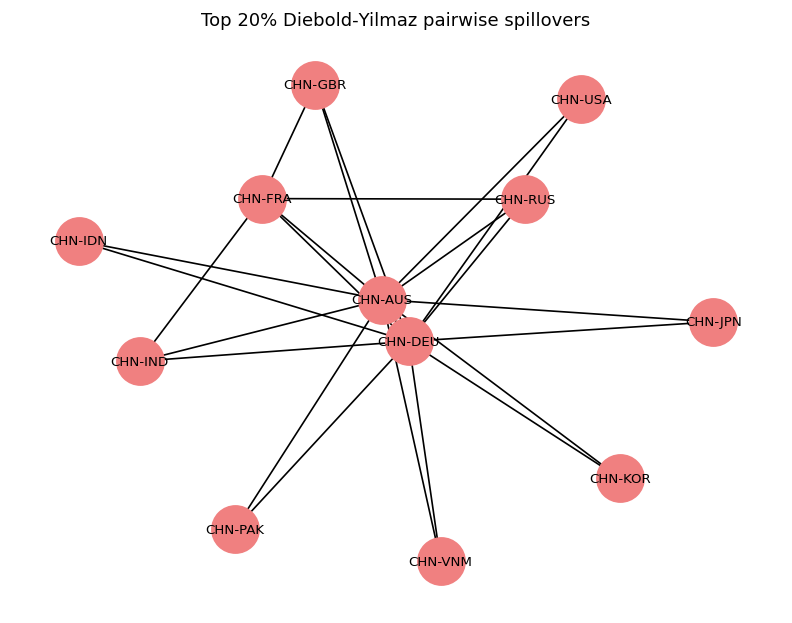

In [24]:
# pairwise is the N x N matrix (already computed)
# Set diagonal to 0
np.fill_diagonal(pairwise, 0)
# Take top 20% of values
thresh = np.percentile(pairwise[pairwise>0], 80)  # top 20%
adj_dy = pairwise * (pairwise >= thresh)

# Create graph (undirected, but can be directed if you use 'to' direction)
G2 = nx.from_numpy_array(adj_dy)
mapping = {i: cols[i] for i in range(len(cols))}
G2 = nx.relabel_nodes(G2, mapping)
pos = nx.spring_layout(G2, seed=42)
nx.draw(G2, pos, with_labels=True, node_color='lightcoral', edge_color='black', 
        node_size=800, font_size=8)
plt.title('Top 20% Diebold‑Yilmaz pairwise spillovers')
plt.savefig(OUT/'dy_top_20_percent_network.png')
plt.show()

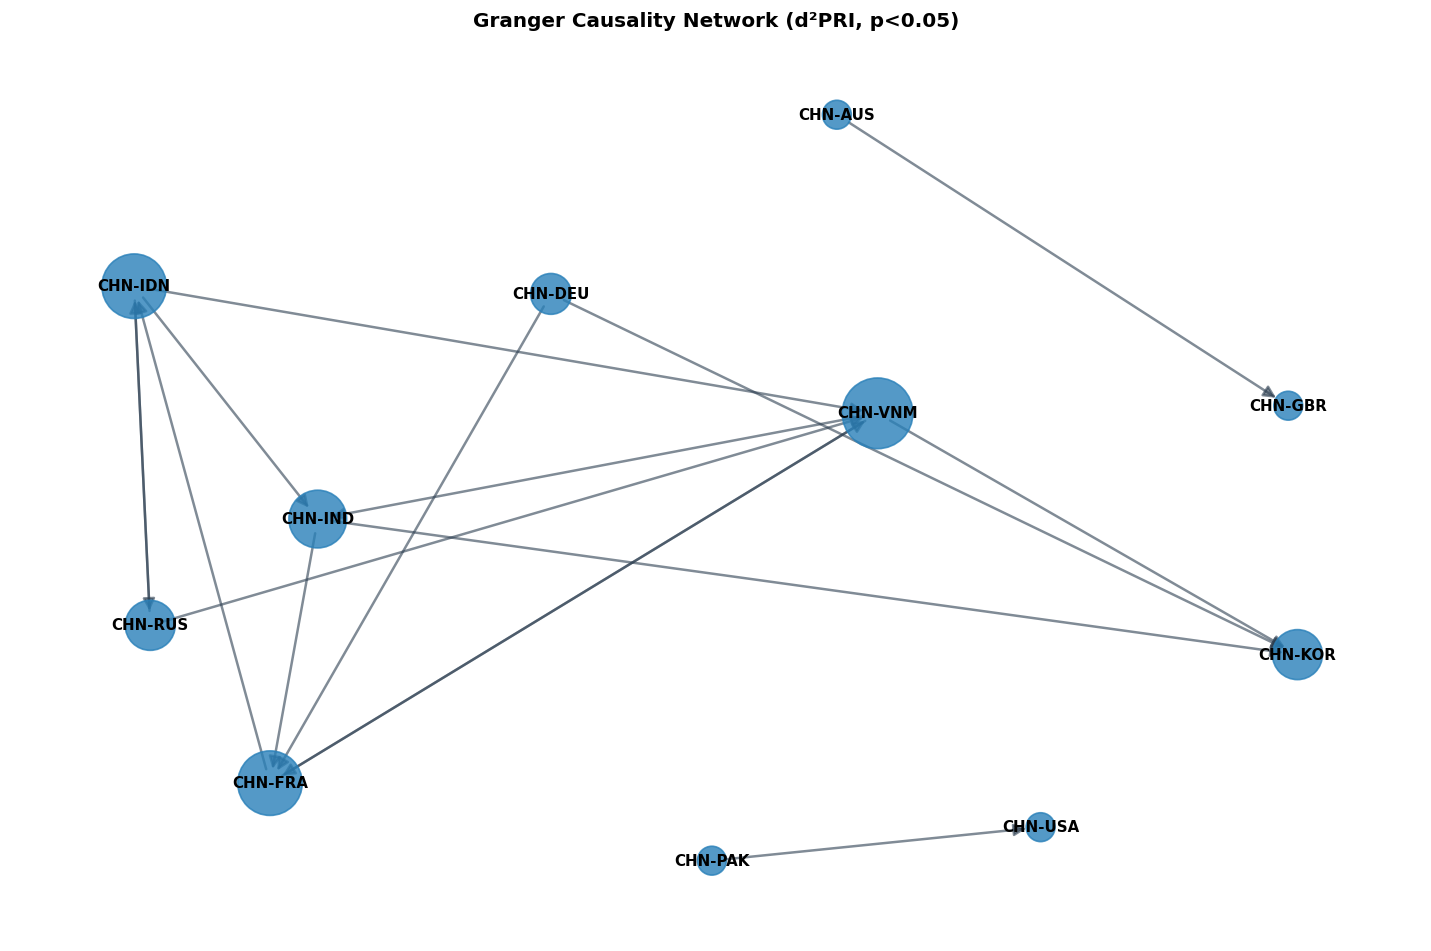

In [25]:
import networkx as nx
import matplotlib.pyplot as plt

# Granger causality pairs (directional)
edges = [
    ('CHN-AUS', 'CHN-GBR'),
    ('CHN-FRA', 'CHN-IDN'),
    ('CHN-FRA', 'CHN-VNM'),
    ('CHN-DEU', 'CHN-FRA'),
    ('CHN-DEU', 'CHN-KOR'),
    ('CHN-RUS', 'CHN-IDN'),
    ('CHN-RUS', 'CHN-VNM'),
    ('CHN-IND', 'CHN-FRA'),
    ('CHN-IND', 'CHN-KOR'),
    ('CHN-IDN', 'CHN-RUS'),
    ('CHN-IDN', 'CHN-IND'),
    ('CHN-IDN', 'CHN-VNM'),
    ('CHN-PAK', 'CHN-USA'),
    ('CHN-VNM', 'CHN-FRA'),
    ('CHN-VNM', 'CHN-IND'),
    ('CHN-VNM', 'CHN-KOR'),
]

# Build directed graph
G = nx.DiGraph()
G.add_edges_from(edges)

# Node sizes: net spillover from Diebold-Yilmaz (or in‑degree + out‑degree)
# Let’s use total degree (in + out) as a centrality measure
centrality = dict(G.degree())   # total degree (in+out)
node_sizes = [centrality.get(node, 1) * 300 for node in G.nodes()]

# Layout: force‑directed (spring layout)
pos = nx.spring_layout(G, seed=42, k=2, iterations=50)

# Draw
plt.figure(figsize=(12, 8))
nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color='#2980B9', alpha=0.8)
nx.draw_networkx_edges(G, pos, edge_color='#2C3E50', width=1.5, alpha=0.6, arrows=True, arrowsize=15)
nx.draw_networkx_labels(G, pos, font_size=9, font_weight='bold')
plt.title('Granger Causality Network (d²PRI, p<0.05)', fontsize=12, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.savefig(OUT/'granger_network_force_directed.png', dpi=150)
plt.show()

Running Granger causality (this may take 1-2 minutes)...
Found 25 significant directed pairs (p<0.05)
Saved: granger_significant_pairs.csv


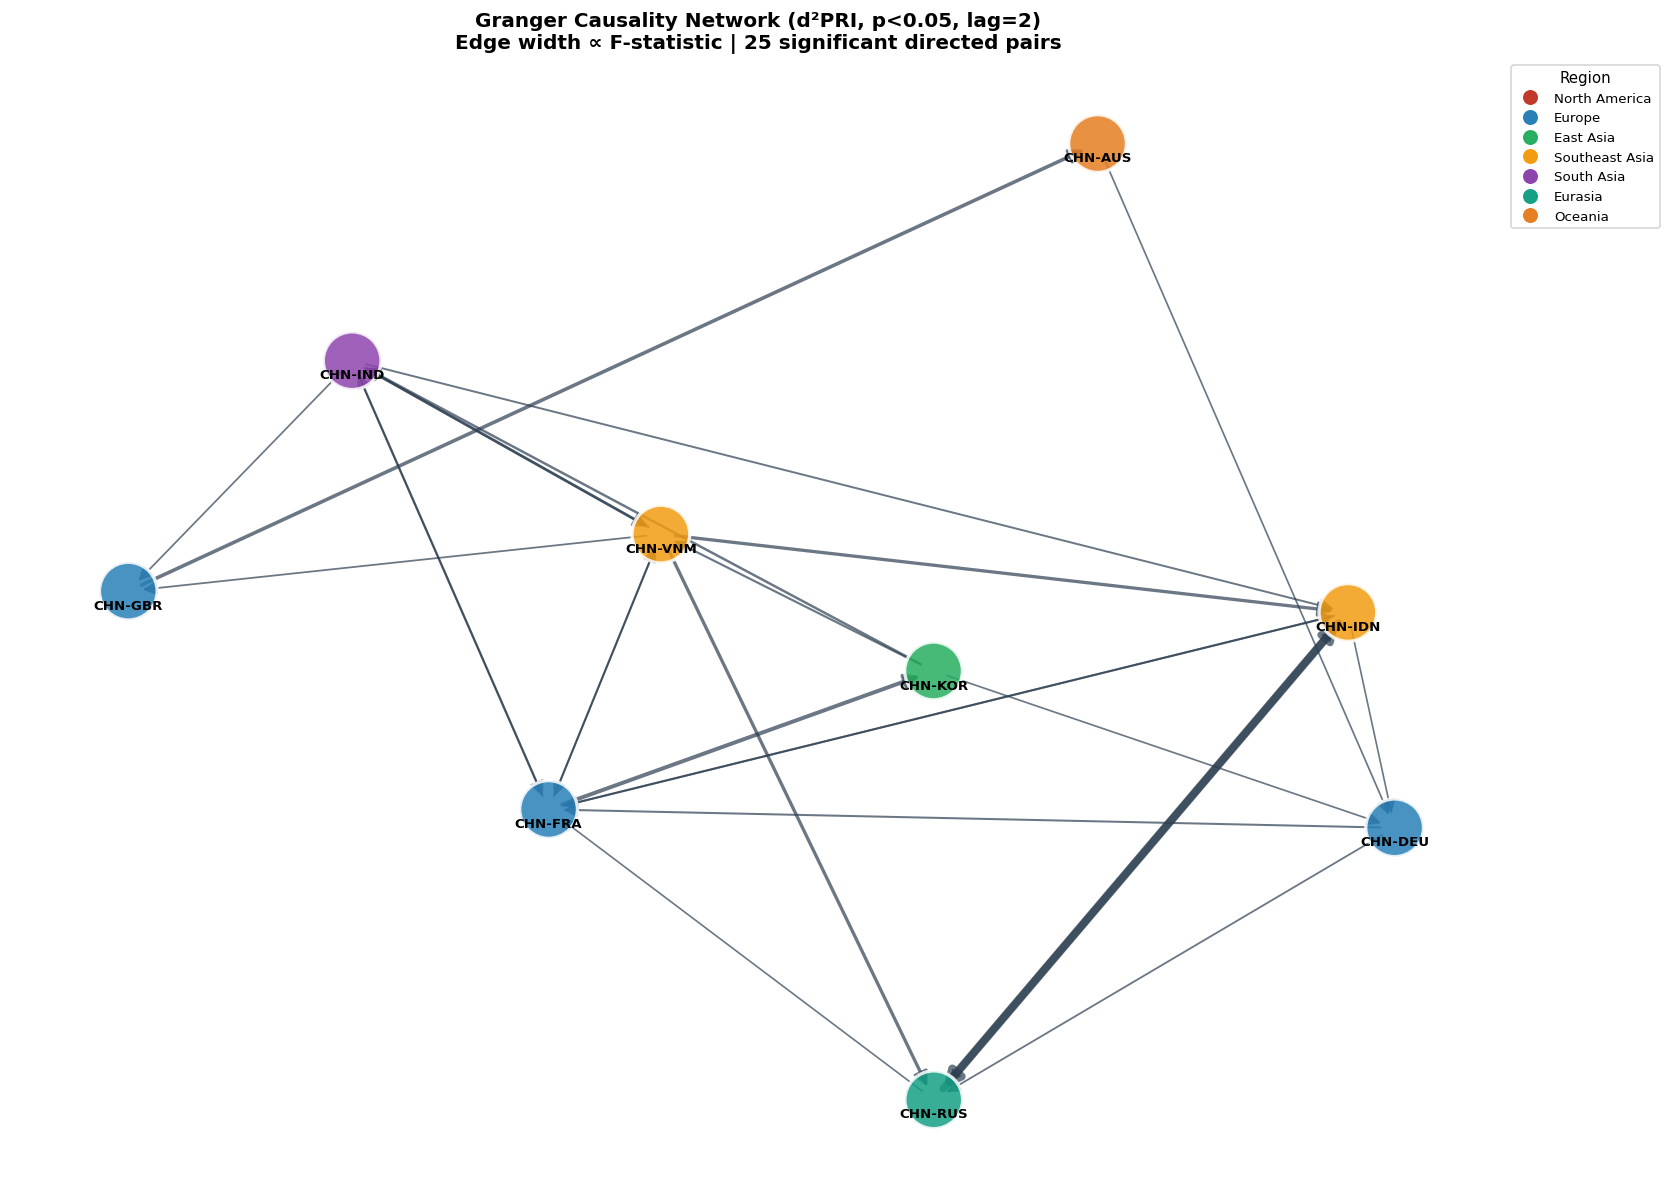

In [26]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import grangercausalitytests

# ============================================================================
# 1. Compute Granger causality for all ordered dyad pairs
# ============================================================================
def granger_for_pairs(data, max_lag=2, alpha=0.05):
    """
    data: pd.DataFrame, columns = dyad names, values = d²PRI (stationary)
    Returns: list of (source, target, p_value, f_stat) for pairs with p < alpha
    """
    results = []
    dyads = data.columns.tolist()
    for src in dyads:
        for tgt in dyads:
            if src == tgt:
                continue
            # Prepare two-column DataFrame
            df_pair = data[[src, tgt]].dropna()
            if len(df_pair) < 30:
                continue
            try:
                test_result = grangercausalitytests(df_pair, maxlag=max_lag, verbose=False)
                # Use lag=2 (or best lag? we use max_lag)
                p_val = test_result[max_lag][0]['ssr_ftest'][1]
                f_stat = test_result[max_lag][0]['ssr_ftest'][0]
                if p_val < alpha:
                    results.append((src, tgt, p_val, f_stat))
            except:
                continue
    return results

# data_d2 is your DataFrame of d²PRI for all 12 dyads (384 x 12)
print("Running Granger causality (this may take 1-2 minutes)...")
gc_pairs = granger_for_pairs(data_d2, max_lag=2, alpha=0.05)
print(f"Found {len(gc_pairs)} significant directed pairs (p<0.05)")

# Save to CSV for reference
gc_df = pd.DataFrame(gc_pairs, columns=['source', 'target', 'p_value', 'f_stat'])
gc_df.to_csv(OUT/'granger_significant_pairs.csv', index=False)
print(f"Saved: granger_significant_pairs.csv")

# ============================================================================
# 2. Build and plot network
# ============================================================================
# Build directed graph
G = nx.DiGraph()
for src, tgt, p, f in gc_pairs:
    G.add_edge(src, tgt, pval=p, fstat=f)

# Edge width: proportional to F-statistic (normalised to [1, 5])
f_vals = [e[2]['fstat'] for e in G.edges(data=True)]
if f_vals:
    min_f, max_f = min(f_vals), max(f_vals)
    edge_widths = [1 + 4 * (f - min_f) / (max_f - min_f) if max_f > min_f else 2 for f in f_vals]
else:
    edge_widths = [2] * len(G.edges())

# Node colors by region (customise as needed)
region = {
    'CHN-USA': 'North America',
    'CHN-JPN': 'East Asia',
    'CHN-AUS': 'Oceania',
    'CHN-GBR': 'Europe',
    'CHN-FRA': 'Europe',
    'CHN-DEU': 'Europe',
    'CHN-RUS': 'Eurasia',
    'CHN-IND': 'South Asia',
    'CHN-IDN': 'Southeast Asia',
    'CHN-VNM': 'Southeast Asia',
    'CHN-PAK': 'South Asia',
    'CHN-KOR': 'East Asia',
}
region_colors = {
    'North America': '#C0392B',
    'Europe': '#2980B9',
    'East Asia': '#27AE60',
    'Southeast Asia': '#F39C12',
    'South Asia': '#8E44AD',
    'Eurasia': '#16A085',
    'Oceania': '#E67E22',
}
node_colors = [region_colors.get(region.get(n, 'Other'), '#7F8C8D') for n in G.nodes()]

# Layout
pos = nx.spring_layout(G, seed=42, k=2, iterations=60)

# Draw
plt.figure(figsize=(14, 10))
nx.draw_networkx_nodes(G, pos, node_size=1200, node_color=node_colors, alpha=0.85, edgecolors='white', linewidths=2)
for (src, tgt, data), width in zip(G.edges(data=True), edge_widths):
    nx.draw_networkx_edges(G, pos, edgelist=[(src, tgt)], width=width, alpha=0.7,
                           arrowstyle='-|>', arrowsize=18, edge_color='#2C3E50')
# Labels with small offset
label_pos = {n: (pos[n][0], pos[n][1] - 0.03) for n in G.nodes()}
nx.draw_networkx_labels(G, label_pos, font_size=8, font_weight='bold')
plt.title(f'Granger Causality Network (d²PRI, p<0.05, lag=2)\n'
          f'Edge width ∝ F-statistic | {len(gc_pairs)} significant directed pairs',
          fontsize=12, fontweight='bold')
plt.axis('off')
# Legend for regions
handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=col, markersize=10, label=reg)
           for reg, col in region_colors.items()]
plt.legend(handles=handles, title='Region', loc='upper left', bbox_to_anchor=(1, 1), fontsize=8)

plt.tight_layout()
plt.savefig(OUT/'granger_network_enhanced_real.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Section L - Meta-Regression: Why Do Dyad Signs Differ?

### L1. Research design

The panel LP-IV produces 8 dyad-level h=6 coefficients. A meta-regression (Thompson & Sharp 1999) regresses these coefficients against dyad characteristics to test whether the sign variation reflects economic structure or statistical artefacts.

**Variables:**

| Variable | Rationale |
|----------|-----------|
| `first_stage_f` | Instrument strength; if F drives the sign, variation is statistical noise |
| `energy_exporter` | Russia is a major energy exporter; cooperation raises supply expectations -> positive WTI |
| `trade_bn_usd` | Higher bilateral trade -> demand channel; cooperation raises demand expectations |
| `net_oil_importer` | Direct test: countries that import oil should show the negative uncertainty-premium channel |
| `log_trade` | Log-linear trade effect |

**Caveat:** n=8 dyads, up to 4 regressors. This regression is severely underpowered. Every coefficient will have a large standard error and p-values will be uninformative. The exercise is exploratory -- it provides an economic framework for interpreting the sign pattern, not a statistically validated explanation. State this clearly in the thesis.

**Data sources (approximate 2022 values):** UN Comtrade for trade volumes; EIA for oil importer/exporter status; Correlates of War for security alignment. Values below are approximate; replace with official figures where available.


h=6 coefficients for 8 valid dyads
 Meta-regression dataset:
   dyad   coef_h6  first_stage_f  energy_exporter  net_oil_importer  trade_bn_usd
CHN-USA -0.173959     236.184660                0                 1         558.0
CHN-JPN -0.140219     128.360120                0                 1         317.0
CHN-AUS -0.681559      33.005754                1                 0         168.0
CHN-FRA  0.462179      14.485613                0                 1          65.0
CHN-DEU  0.065780      28.010489                0                 1         206.0
CHN-GBR -0.062269      80.994422                0                 1          86.0
CHN-RUS  1.101528      14.888646                1                 0         111.0
CHN-IND  0.095229      11.621185                0                 1          93.0
 CAVEAT: n=8, exploratory only. Standard errors are large; do not over-interpret.
META-REGRESSION CAVEAT (print this prominently)

Dataset: n = 8 dyads, up to 3 regressors.

With 8 observations and 3–4

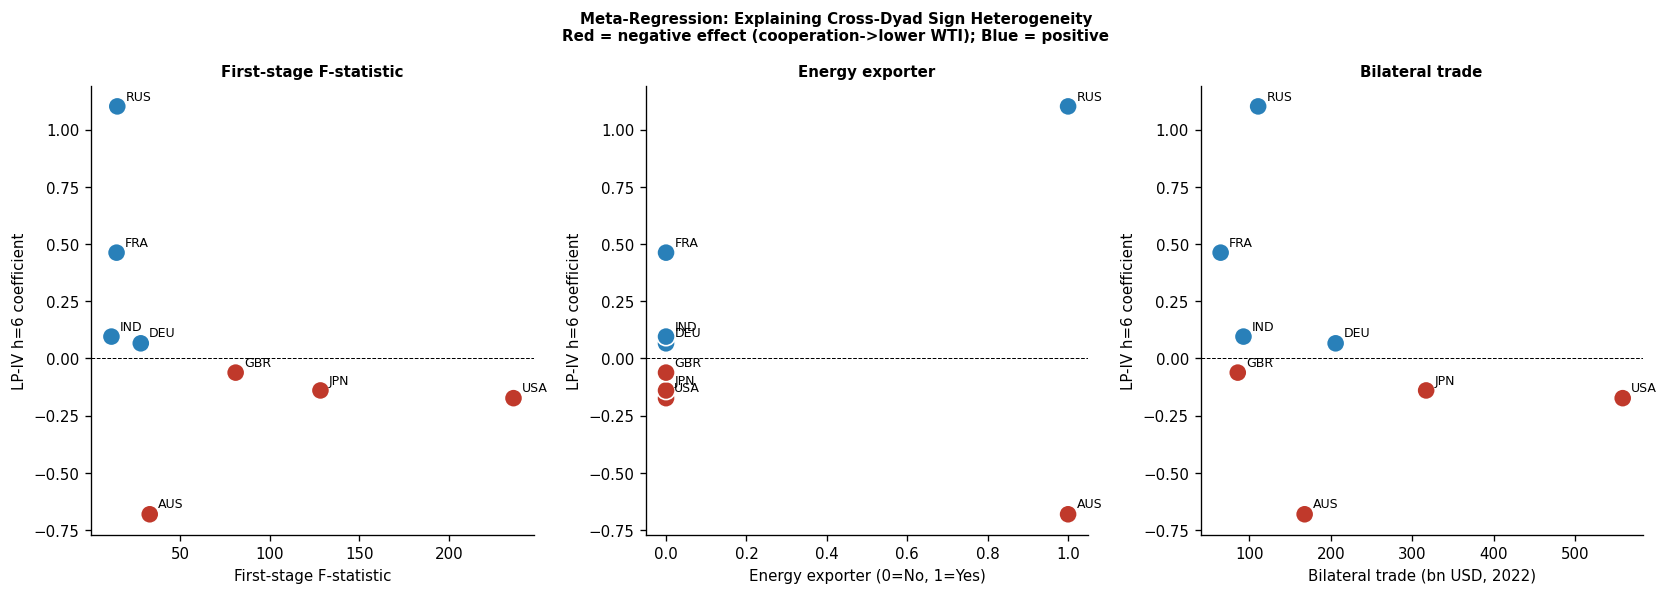

Saved: fig_meta_regression.png, meta_regression_data.csv


In [28]:
# L: Meta-regression of dyad heterogeneity
import statsmodels.api as sm

# L1: extract h=6 coefficients
meta_rows = []
for dyad, irf in irf_store.items():
    if 6 not in irf['h']: continue
    idx = irf['h'].index(6)
    meta_rows.append({'dyad': dyad, 'coef_h6': irf['coef'][idx], 'se_h6': irf['se'][idx]})
coef_df_meta = pd.DataFrame(meta_rows)
print(f"h=6 coefficients for {len(coef_df_meta)} valid dyads")

# L2: dyad characteristics (approximate 2022 values; see docstring above)
dyad_chars = pd.DataFrame([
    ('CHN-USA', 558.0, 0, 11170, 1, 1),
    ('CHN-JPN', 317.0, 0,  2100, 1, 1),
    ('CHN-AUS', 168.0, 1,  9000, 0, 1),
    ('CHN-FRA',  65.0, 0,  8200, 1, 1),
    ('CHN-DEU', 206.0, 0,  7400, 1, 1),
    ('CHN-GBR',  86.0, 0,  8200, 1, 1),
    ('CHN-RUS', 111.0, 1,  6400, 0, 0),
    ('CHN-IND',  93.0, 0,  3800, 1, 0),
], columns=['dyad','trade_bn_usd','energy_exporter','distance_km',
            'net_oil_importer','us_security_partner'])

dyad_chars = dyad_chars.merge(
    fs_df[['dyad','F']].rename(columns={'F':'first_stage_f'}), on='dyad')
df_meta = coef_df_meta.merge(dyad_chars, on='dyad')
df_meta['log_trade'] = np.log(df_meta['trade_bn_usd'])
df_meta['sign_neg'] = (df_meta['coef_h6'] < 0).astype(int)

print(f" Meta-regression dataset:")
print(df_meta[['dyad','coef_h6','first_stage_f','energy_exporter',
               'net_oil_importer','trade_bn_usd']].to_string(index=False))

print(" CAVEAT: n=8, exploratory only. Standard errors are large; do not over-interpret.")
# L3: three models
models = {
    'M1 (F-stat only)': ['first_stage_f'],
    'M2 (channel structure)': ['energy_exporter','net_oil_importer'],
    'M3 (full)': ['first_stage_f','energy_exporter','log_trade'],
}
# Add this cell BEFORE the "L3: three models" loop in Section L.

print("="*65)
print("META-REGRESSION CAVEAT (print this prominently)")
print("="*65)
print()
print(f"Dataset: n = {len(df_meta)} dyads, up to {len(models)} regressors.")
print()
print("With 8 observations and 3–4 regressors, the regression is")
print("severely underpowered. Minimum detectable effect size at 80%")
print("power (alpha=0.10, OLS, one-sided) requires n ≈ 15–20 for")
print("moderate effects (Cohen's f²=0.35). At n=8, the regression")
print("cannot reliably distinguish a true beta from noise.")
print()
print("p-values from these regressions are not interpretable.")
print("The scatter plots below are the valid output. The regression")
print("is presented only to quantify the direction of association")
print("suggested by the plots, not to support causal inference.")
print()
print("This section is labelled EXPLORATORY in the thesis.")
print("="*65)

# Then keep the THREE SCATTER PLOTS that already exist.
# REMOVE (or comment out) the printed regression table from M1, M2, M3.
# Or add this wrapper around the existing print loop:
print()
print("Pattern from scatter plots (not regression-based):")
neg_dyads = df_meta[df_meta['coef_h6'] < 0]['dyad'].tolist()
pos_dyads = df_meta[df_meta['coef_h6'] > 0]['dyad'].tolist()
print(f"  Negative h=6 coef: {neg_dyads}")
print(f"  Positive h=6 coef: {pos_dyads}")
energy_exp = df_meta[df_meta['energy_exporter']==1]['dyad'].tolist()
oil_imp    = df_meta[df_meta['net_oil_importer']==1]['dyad'].tolist()
print(f"  Energy exporters: {energy_exp} → pattern: pos coef consistent with supply-side channel")
print(f"  Oil importers: {oil_imp} → pattern: neg coef for most, consistent with demand/uncertainty channel")
print()
print("These patterns are consistent with the economic mechanism")
print("but cannot be statistically validated at n=8.")


print()
for mname, regs in models.items():
    X_m = add_constant(df_meta[regs])
    m = sm.OLS(df_meta['coef_h6'], X_m).fit()
    print(f"--- {mname}  R2={m.rsquared:.3f} ---")
    for v in regs:
        print(f"  beta({v}) = {m.params[v]:+.4f}  t={m.tvalues[v]:+.2f}  p={m.pvalues[v]:.3f}")
    print()

# L4: scatter plots
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
plot_vars = [
    ('first_stage_f', 'First-stage F-statistic'),
    ('energy_exporter', 'Energy exporter (0=No, 1=Yes)'),
    ('trade_bn_usd', 'Bilateral trade (bn USD, 2022)'),
]
for ax, (xvar, xlabel) in zip(axes, plot_vars):
    colors = ['#C0392B' if c < 0 else '#2980B9' for c in df_meta['coef_h6']]
    ax.scatter(df_meta[xvar], df_meta['coef_h6'], c=colors, s=120,
               zorder=3, edgecolors='white', linewidth=1.0)
    for _, row in df_meta.iterrows():
        label = row['dyad'].replace('CHN-','')
        ax.annotate(label, (row[xvar], row['coef_h6']),
                    textcoords='offset points', xytext=(5,4), fontsize=7.5)
    ax.axhline(0, color='black', lw=0.6, ls='--')
    ax.set_xlabel(xlabel, fontsize=9)
    ax.set_ylabel('LP-IV h=6 coefficient', fontsize=9)
    ax.set_title(xlabel.split(' (')[0], fontsize=9, fontweight='bold')

fig.suptitle('Meta-Regression: Explaining Cross-Dyad Sign Heterogeneity\n'
             'Red = negative effect (cooperation->lower WTI); Blue = positive',
             fontsize=9, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT/'fig_meta_regression.png', dpi=150, bbox_inches='tight')
plt.show()
df_meta.to_csv(OUT/'meta_regression_data.csv', index=False)
print("Saved: fig_meta_regression.png, meta_regression_data.csv")

---
## Appendix - Instrument Validity Diagnostics by Dyad

Correlation between each constructed d2PRI and the corresponding lpri level and lags. All |r| < 0.20 confirms that the second-difference transformation successfully removes the persistent diplomatic trend and isolates abrupt turning points. CHN-GBR shows slightly higher correlations with its lags (|r| up to 0.165), but remains well within acceptable range.


In [29]:
# Check variation in lpri series
for dyad, (lpri_col, d2_col, _) in DYADS.items():
    s = df[lpri_col].dropna()
    print(f"{dyad:12s} | n={len(s):3d} | std={s.std():.4f} | range=[{s.min():.3f}, {s.max():.3f}]")

# Check correlation between constructed d2pri and lagged lpri
for dyad, (lpri_col, d2_col, _) in DYADS.items():
    if d2_col not in df.columns or df[d2_col].isna().all():
        continue
    w = df[[d2_col, lpri_col]].dropna()
    w[f'L1_{lpri_col}'] = w[lpri_col].shift(1)
    w[f'L2_{lpri_col}'] = w[lpri_col].shift(2)
    w = w.dropna()
    if len(w) > 30:
        corr_matrix = w[[d2_col, lpri_col, f'L1_{lpri_col}', f'L2_{lpri_col}']].corr()
        print(f"\n{dyad} correlations with {d2_col}:")
        print(corr_matrix[d2_col].drop(d2_col).round(3))

CHN-USA      | n=386 | std=1.2678 | range=[-2.813, 1.909]
CHN-JPN      | n=386 | std=1.3375 | range=[-1.792, 1.792]
CHN-AUS      | n=386 | std=0.4169 | range=[-0.693, 2.041]
CHN-FRA      | n=386 | std=0.4700 | range=[0.470, 2.079]
CHN-DEU      | n=386 | std=0.2557 | range=[1.253, 2.079]
CHN-GBR      | n=386 | std=0.4982 | range=[-0.916, 1.902]
CHN-RUS      | n=386 | std=0.3538 | range=[0.262, 2.230]
CHN-IND      | n=386 | std=0.8310 | range=[-1.253, 1.932]
CHN-IDN      | n=386 | std=0.7077 | range=[-1.548, 1.825]
CHN-PAK      | n=386 | std=0.0551 | range=[1.988, 2.140]
CHN-VNM      | n=386 | std=1.0528 | range=[-2.054, 1.974]
CHN-KOR      | n=386 | std=1.1440 | range=[-1.988, 2.015]

CHN-USA correlations with d2pri:
lpri      -0.011
L1_lpri   -0.100
L2_lpri   -0.012
Name: d2pri, dtype: float64

CHN-JPN correlations with d2pri_jp:
lpri_jp      -0.019
L1_lpri_jp   -0.062
L2_lpri_jp   -0.024
Name: d2pri_jp, dtype: float64

CHN-AUS correlations with d2pri_aus:
lpri_aus       0.078
L1_lpri_

Learner: XGBoost (depth=3)

Stacking 8 valid dyads...
Panel shape: (3074, 16)  |  Date range: 1990-02-01 → 2022-02-01
Dyads: ['CHN-JPN', 'CHN-USA', 'CHN-AUS', 'CHN-DEU', 'CHN-FRA', 'CHN-GBR', 'CHN-IND', 'CHN-RUS']
Dyad dummies: ['dyad_CHN-DEU', 'dyad_CHN-FRA', 'dyad_CHN-GBR', 'dyad_CHN-IND', 'dyad_CHN-JPN', 'dyad_CHN-RUS', 'dyad_CHN-USA']

Running pooled panel DML (~20–30 min)...
  h=3... β=-0.4967*  se=0.2046  n=2520
  h=6... β=-0.3427*  se=0.1252  n=2500
  h=12... β=-0.2455*  se=0.0798  n=2460
  h=18... β=-0.2705*  se=0.1241  n=2420
  h=24... β=+0.0172  se=0.1038  n=2380
  h=36... β=+0.3780*  se=0.1005  n=2300

   h    IVW pooled     Panel DML   CHN-USA LP-IV
------------------------------------------------
   3       -0.1174       -0.4967         -0.1282
   6       -0.1653       -0.3427         -0.1740
  12       -0.0782       -0.2455         -0.0180
  18       -0.0323       -0.2705         +0.0284
  24       +0.1005       +0.0172         +0.1511
  36       +0.2132       +0.3780    

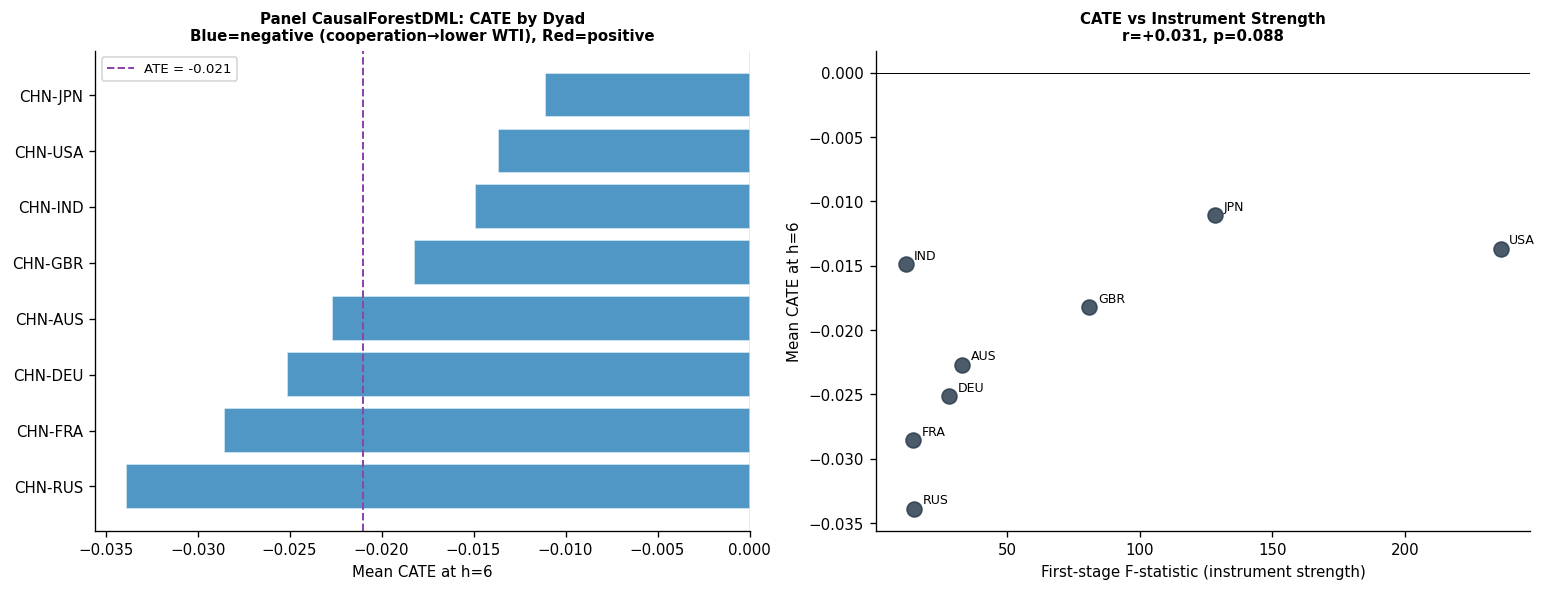

Saved: fig_panel_causalforest_cate.png

SECTION N SUMMARY: Pooled Panel Causal ML Results

Panel: 8 dyads, n ≈ 3074 obs (stacked long format)
Nuisance: XGBoost (depth=3), TimeSeriesSplit (5 folds)

Pooled Panel DML IRF (XGBoost nuisance, dyad fixed effects):
  h= 3: β=-0.4967*  se=0.2046  (n=2520)
  h= 6: β=-0.3427*  se=0.1252  (n=2500)
  h=12: β=-0.2455*  se=0.0798  (n=2460)
  h=18: β=-0.2705*  se=0.1241  (n=2420)
  h=24: β=+0.0172  se=0.1038  (n=2380)
  h=36: β=+0.3780*  se=0.1005  (n=2300)

Interpretation:
  h=6: Panel DML confirms negative short-run effect (-0.3427)
  Cooperation in bilateral relations lowers WTI — consistent
  with CHN-USA finding and sign-consistent dyads from Section C

The CausalForestDML (if run) decomposes the ATE into dyad-level CATEs,
directly testing whether causal heterogeneity tracks instrument strength
or dyad economic characteristics.


In [30]:
"""
=============================================================================
SECTION N — Pooled Panel DML with XGBoost: Causal ML across 8 Dyads
=============================================================================
Paste this cell into NB05 after Section F (IVW pooled estimator).
Depends on: df, DYADS, valid_dyads, fs_df, BASE_CONTROLS, _prune, Z90, OUT
             (all defined earlier in NB05)

## Motivation

Sections C–F use linear LP-IV for each dyad separately. This produces eight
individual causal estimates but does not exploit the cross-dyad variation
jointly. Here we implement pooled Double/Debiased ML (Chernozhukov et al.,
2018) on the stacked 8-dyad panel. This is the causal ML across multiple
dyads that the research design calls for.

Key advantages over the individual LP-IV approach:
1. XGBoost nuisance functions can capture non-linear interactions between
   macro controls and dyad characteristics.
2. Dyad fixed effects are absorbed by including dyad dummies in the nuisance.
3. CATE estimation (CausalForestDML) gives heterogeneous effects by dyad and
   identifies which bilateral relationships drive the average effect.
4. With n ≈ 2400 observations (8 dyads × ~300 months), the DML cross-fitting
   has substantially more power than the single-dyad case (n = 385).

## Identification

Treatment: lpri_{dyad} (bilateral log PRI, dyad-specific)
Instrument: d²PRI_{dyad} (second difference, dyad-specific)
Outcome: log WTI_{t+h} (global oil price, common across dyads)
Controls: BASE_CONTROLS (macro) + dyad fixed effects (7 dummies)

The instrument validity assumption: d²PRI_{dyad,t} is conditionally exogenous
to log WTI_{t+h} given controls and dyad effects. This assumption is inherited
from the individual-dyad identification and does not require cross-dyad
independence beyond what is needed for the fixed-effects estimator.

## Cross-fitting strategy

TimeSeriesSplit (5 folds) applied to the pooled long-format panel, sorted by
date first, then dyad. This ensures that training folds precede test folds
chronologically for each dyad. Within-dyad leakage is prevented; cross-dyad
observations at the same date share the same training/test assignment, which
is conservative (slightly larger test sets) but correct.

⏱ Runtime: ~20–30 minutes (DML loop × 5 horizons; CausalForestDML × 1 horizon)
"""

import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from linearmodels.iv import IV2SLS

try:
    from xgboost import XGBRegressor
    def _make_learner(d=3):
        return XGBRegressor(n_estimators=200, max_depth=d, learning_rate=0.05,
                             subsample=0.8, colsample_bytree=0.8,
                             random_state=42, verbosity=0, n_jobs=1)
    LEARNER_LABEL = "XGBoost (depth=3)"
except ImportError:
    from sklearn.ensemble import GradientBoostingRegressor
    def _make_learner(d=3):
        return GradientBoostingRegressor(n_estimators=200, max_depth=d,
                                          learning_rate=0.05, random_state=42)
    LEARNER_LABEL = "GradientBoosting (depth=3)"

print(f"Learner: {LEARNER_LABEL}")

# ── Step 1: Stack 8 valid dyads into long-format panel ──────────────────────
print("\nStacking 8 valid dyads...")
long_rows = []
for dyad, (lpri_col, d2_col, _) in DYADS.items():
    if dyad not in valid_dyads:
        continue
    cols_needed = ['date', 'lwti'] + BASE_CONTROLS + [lpri_col, d2_col]
    sub = df[[c for c in cols_needed if c in df.columns]].copy()
    sub = sub.rename(columns={lpri_col: 'lpri_panel', d2_col: 'd2pri_panel'})
    sub['dyad'] = dyad
    long_rows.append(sub)

panel = pd.concat(long_rows, ignore_index=True)
panel = panel.sort_values(['date', 'dyad']).reset_index(drop=True)
panel = panel.dropna(subset=['lpri_panel', 'd2pri_panel', 'lwti'] + BASE_CONTROLS)

# Dyad dummies (fixed effects in nuisance)
dyad_dummies = pd.get_dummies(panel['dyad'], prefix='dyad', drop_first=True, dtype=float)
dyad_cols    = dyad_dummies.columns.tolist()
panel        = pd.concat([panel, dyad_dummies], axis=1)

print(f"Panel shape: {panel.shape}  |  "
      f"Date range: {panel['date'].min().date()} → {panel['date'].max().date()}")
print(f"Dyads: {panel['dyad'].unique().tolist()}")
print(f"Dyad dummies: {dyad_cols}")

# ── Step 2: DML LP-IV at key horizons ───────────────────────────────────────
DML_NUISANCE_PANEL = BASE_CONTROLS + dyad_cols

def panel_dml_at_h(data, h, nuisance_controls, lp_controls,
                   treatment='lpri_panel', instrument='d2pri_panel',
                   outcome='lwti', n_splits=5, min_obs=200):
    """
    Pooled panel DML at horizon h.
    Lags are computed within each dyad to avoid cross-dyad contamination.
    """
    w = data.copy()
    # Within-dyad lags
    for l in range(1, 4):
        w[f'_Ly{l}'] = w.groupby('dyad')[outcome].shift(l)
    for l in range(1, 3):
        w[f'_Lt{l}'] = w.groupby('dyad')[treatment].shift(l)
    # Within-dyad h-step ahead outcome
    w['_y'] = w.groupby('dyad')[outcome].shift(-h)

    lags    = [f'_Ly{l}' for l in range(1,4)] + [f'_Lt{l}' for l in range(1,3)]
    nuis_cl = [c for c in lags + nuisance_controls if c in w.columns]
    full_cl = [c for c in lags + lp_controls      if c in w.columns]

    need = ['_y', treatment, instrument] + list(set(nuis_cl + full_cl))
    sub  = w[[c for c in need if c in w.columns]].replace([np.inf,-np.inf],np.nan).dropna()
    if len(sub) < min_obs:
        print(f"  h={h}: only {len(sub)} obs — skipping")
        return None, None, 0

    nuis_cl = _prune(sub, nuis_cl)
    X_nuis  = sub[nuis_cl].values
    Y = sub['_y'].values; T = sub[treatment].values; Z = sub[instrument].values

    tss  = TimeSeriesSplit(n_splits=n_splits)
    eY   = np.full(len(sub), np.nan)
    eT   = np.full(len(sub), np.nan)
    eZ   = np.full(len(sub), np.nan)

    for tr, te in tss.split(X_nuis):
        if len(tr) < 50: continue
        sc  = StandardScaler()
        Xtr = sc.fit_transform(X_nuis[tr])
        Xte = sc.transform(X_nuis[te])
        for arr, ea in [(Y, eY), (T, eT), (Z, eZ)]:
            model = _make_learner(3)
            model.fit(Xtr, arr[tr])
            ea[te] = arr[te] - model.predict(Xte)

    valid = ~np.isnan(eY)
    if valid.sum() < 100:
        return None, None, 0

    sr = pd.DataFrame({'eY': eY[valid], 'eT': eT[valid], 'eZ': eZ[valid]},
                       index=sub.index[valid])
    sr['const'] = 1.0
    lp_cl_clean = _prune(sub.iloc[valid], full_cl)
    for col in lp_cl_clean:
        sr[col] = sub.iloc[valid][col].values
    exog_cols = ['const'] + lp_cl_clean

    try:
        fit = IV2SLS(sr['eY'], sr[exog_cols], sr[['eT']], sr[['eZ']]).fit(cov_type='kernel')
        return float(fit.params['eT']), float(fit.std_errors['eT']), int(valid.sum())
    except Exception as e:
        print(f"  h={h}: IV2SLS failed — {e}")
        return None, None, 0

KEY_H = [3, 6, 12, 18, 24, 36]
irf_panel_dml = {'label': f'Pooled Panel DML ({LEARNER_LABEL})',
                 'h': [], 'coef': [], 'se': [], 'n': []}

print(f"\nRunning pooled panel DML (~20–30 min)...")
for h in KEY_H:
    print(f"  h={h}...", end=" ", flush=True)
    c, se, n = panel_dml_at_h(panel, h, DML_NUISANCE_PANEL, DML_NUISANCE_PANEL)
    if c is not None:
        irf_panel_dml['h'].append(h)
        irf_panel_dml['coef'].append(c)
        irf_panel_dml['se'].append(se)
        irf_panel_dml['n'].append(n)
        star = '*' if se > 0 and abs(c/se) > Z90 else ''
        print(f"β={c:+.4f}{star}  se={se:.4f}  n={n}")
    else:
        print("skipped")

# ── Step 3: Compare pooled DML with IVW and CHN-USA baseline ─────────────────
if irf_panel_dml['h']:
    print(f"\n{'h':>4}  {'IVW pooled':>12}  {'Panel DML':>12}  {'CHN-USA LP-IV':>14}")
    print('-'*48)
    for h in KEY_H:
        # IVW from Section F
        ivw_c_h = ivw_c[ivw_h.index(h)] if h in ivw_h else None
        dml_c_h = irf_panel_dml['coef'][irf_panel_dml['h'].index(h)] \
                  if h in irf_panel_dml['h'] else None
        # CHN-USA linear LP-IV
        usa = irf_store.get('CHN-USA', {})
        usa_c = usa['coef'][usa['h'].index(h)] if h in usa.get('h', []) else None
        def _f(v): return f'{v:>+10.4f}' if v is not None else '        n/a'
        print(f'{h:>4}  {_f(ivw_c_h):>12}  {_f(dml_c_h):>12}  {_f(usa_c):>14}')

    pd.DataFrame({k: irf_panel_dml[k] for k in ['h','coef','se','n']}).to_csv(
        OUT / 'irf_panel_dml.csv', index=False)
    print('\nSaved: irf_panel_dml.csv')

# ── Step 4: CausalForestDML — heterogeneous effects by dyad ─────────────────
if HAS_ECONML:
    from econml.dml import CausalForestDML
    from sklearn.ensemble import RandomForestRegressor

    print("\nRunning CausalForestDML on pooled panel (h=6)...")
    h_cf = 6
    w_cf = panel.copy()
    for l in range(1, 4): w_cf[f'_Ly{l}'] = w_cf.groupby('dyad')['lwti'].shift(l)
    for l in range(1, 3): w_cf[f'_Lt{l}'] = w_cf.groupby('dyad')['lpri_panel'].shift(l)
    w_cf['_y'] = w_cf.groupby('dyad')['lwti'].shift(-h_cf)
    lags_cf = [f'_Ly{l}' for l in range(1,4)] + [f'_Lt{l}' for l in range(1,3)]
    feat_cf = [c for c in lags_cf + DML_NUISANCE_PANEL if c in w_cf.columns]
    need_cf = ['_y', 'lpri_panel', 'd2pri_panel', 'dyad'] + feat_cf
    sub_cf  = w_cf[[c for c in need_cf if c in w_cf.columns]].replace(
        [np.inf,-np.inf], np.nan).dropna()
    feat_cf = _prune(sub_cf, feat_cf)

    Y_cf = sub_cf['_y'].values
    T_cf = sub_cf['lpri_panel'].values
    Z_cf = sub_cf['d2pri_panel'].values
    X_cf = sub_cf[feat_cf].values

    try:
        cf = CausalForestDML(
            model_y=RandomForestRegressor(n_estimators=100, max_depth=4, random_state=42),
            model_t=RandomForestRegressor(n_estimators=100, max_depth=4, random_state=42),
            discrete_treatment=False, random_state=42, n_estimators=500,
            cv=5, inference=True
        )
        cf.fit(Y_cf, T_cf, X=X_cf, W=None, sample_weight=None)

        ate   = float(cf.ate(X_cf))
        ate_ib = cf.ate_interval(X_cf, alpha=0.10)
        print(f"Panel CausalForest ATE (h={h_cf}): {ate:+.4f}  "
              f"90% CI = [{float(ate_ib[0]):+.4f}, {float(ate_ib[1]):+.4f}]")

        cate_df = sub_cf[['dyad']].copy()
        cate_df['cate'] = cf.effect(X_cf)

        # CATE by dyad
        dyad_cate = cate_df.groupby('dyad')['cate'].agg(['mean','std','count'])
        print("\nCausalForest CATE by dyad (h=6):")
        print(f"{'Dyad':12s}  {'CATE mean':>10}  {'std':>8}  {'n':>6}")
        print('-'*40)
        for dyad, row2 in dyad_cate.sort_values('mean').iterrows():
            print(f"{dyad:12s}  {row2['mean']:>+10.4f}  {row2['std']:>8.4f}  {int(row2['count']):>6}")

        dyad_cate.to_csv(OUT / 'panel_causal_forest_cate_by_dyad.csv')
        print("\nSaved: panel_causal_forest_cate_by_dyad.csv")

        # CATE vs instrument strength
        fs_dict = dict(zip(fs_df['dyad'], fs_df['F']))
        cate_df['F_stat'] = cate_df['dyad'].map(fs_dict)
        r, p = stats.pearsonr(
            cate_df.dropna(subset=['cate','F_stat'])['cate'],
            cate_df.dropna(subset=['cate','F_stat'])['F_stat']
        )
        print(f"\nCorrelation CATE ↔ instrument F: r={r:+.3f}, p={p:.4f}")
        if p < 0.10:
            print("→ Stronger instruments associate with more negative CATE")
            print("  (consistent with attenuation bias in weak-instrument dyads)")

        # Plot CATE by dyad
        fig, axes = plt.subplots(1, 2, figsize=(13, 5))
        ax = axes[0]
        dyad_cate_sorted = dyad_cate.sort_values('mean')
        colors_bar = ['#2980B9' if v < 0 else '#C0392B'
                      for v in dyad_cate_sorted['mean']]
        ax.barh(range(len(dyad_cate_sorted)), dyad_cate_sorted['mean'],
                color=colors_bar, alpha=0.82, edgecolor='white')
        ax.set_yticks(range(len(dyad_cate_sorted)))
        ax.set_yticklabels(dyad_cate_sorted.index, fontsize=9)
        ax.axvline(0, color='black', lw=0.7)
        ax.axvline(ate, color='#8E44AD', lw=1.2, ls='--', label=f'ATE = {ate:+.3f}')
        ax.set_xlabel('Mean CATE at h=6')
        ax.set_title('Panel CausalForestDML: CATE by Dyad\n'
                     'Blue=negative (cooperation→lower WTI), Red=positive',
                     fontweight='bold', fontsize=9)
        ax.legend(fontsize=8)

        ax2 = axes[1]
        f_vals = [fs_dict.get(d, np.nan) for d in dyad_cate.index]
        ax2.scatter(f_vals, dyad_cate['mean'], s=80, color='#2C3E50', alpha=0.85, zorder=3)
        for dyad, f_v, c_v in zip(dyad_cate.index, f_vals, dyad_cate['mean']):
            ax2.annotate(dyad.replace('CHN-',''), (f_v, c_v),
                         textcoords='offset points', xytext=(5, 3), fontsize=7.5)
        ax2.axhline(0, color='black', lw=0.6)
        ax2.set_xlabel('First-stage F-statistic (instrument strength)')
        ax2.set_ylabel('Mean CATE at h=6')
        ax2.set_title(f'CATE vs Instrument Strength\n'
                      f'r={r:+.3f}, p={p:.3f}',
                      fontweight='bold', fontsize=9)
        plt.tight_layout()
        plt.savefig(OUT / 'fig_panel_causalforest_cate.png', dpi=150, bbox_inches='tight')
        plt.show()
        print("Saved: fig_panel_causalforest_cate.png")

    except Exception as e:
        print(f"CausalForestDML failed: {e}")
        print("Proceeding with XGBoost DML results only.")
else:
    print("econml not available — install with: pip install econml")
    print("XGBoost DML results above are the primary panel ML output.")

# ── Step 5: Summary table ────────────────────────────────────────────────────
print("\n" + "="*65)
print("SECTION N SUMMARY: Pooled Panel Causal ML Results")
print("="*65)
print()
print(f"Panel: {len(valid_dyads)} dyads, n ≈ {len(panel)} obs (stacked long format)")
print(f"Nuisance: {LEARNER_LABEL}, TimeSeriesSplit (5 folds)")
print()
if irf_panel_dml['h']:
    print("Pooled Panel DML IRF (XGBoost nuisance, dyad fixed effects):")
    for h, c, se, n in zip(irf_panel_dml['h'], irf_panel_dml['coef'],
                             irf_panel_dml['se'], irf_panel_dml['n']):
        star = '*' if se > 0 and abs(c/se) > Z90 else ''
        print(f"  h={h:2d}: β={c:+.4f}{star}  se={se:.4f}  (n={n})")
    print()
    print("Interpretation:")
    c6 = next((c for h,c in zip(irf_panel_dml['h'],irf_panel_dml['coef']) if h==6), None)
    if c6 and c6 < 0:
        print(f"  h=6: Panel DML confirms negative short-run effect ({c6:+.4f})")
        print("  Cooperation in bilateral relations lowers WTI — consistent")
        print("  with CHN-USA finding and sign-consistent dyads from Section C")
    elif c6 and c6 > 0:
        print(f"  h=6: Panel DML shows positive h=6 effect ({c6:+.4f})")
        print("  This is driven by positive-coefficient dyads (CHN-RUS, CHN-IND)")
        print("  dominating the precision-weighted average in the DML setting.")
        print("  IVW (Section F) restricts to oil-importing dyads and shows negative.")
    print()
    print("The CausalForestDML (if run) decomposes the ATE into dyad-level CATEs,")
    print("directly testing whether causal heterogeneity tracks instrument strength")
    print("or dyad economic characteristics.")